# 06 - LSTM Architecture Audit (Cumulative) — 20.03.2026

This notebook starts the architecture-first phase for the thesis. It is intentionally **gated**:

- Step 1 audits the current notebook logic and upstream data flow.
- No model training is allowed until this audit is reviewed.
- If blocking issues are found, they are logged here and fixed later one-by-one.


## Step 1 - Pre-training logic audit only

The purpose of this step is to inspect the current notebook chain and confirm whether the architecture audit can safely proceed.

The audit covers:

- `01_thesis_data_pipeline_09032026.ipynb`
- `03_feature_engineering_10032026.ipynb`
- `04_lstm_experiments_10032026.ipynb`
- `05_long_horizon_inertia_experiments_16032026.ipynb`

The checks focus on:

- split chronology and boundaries,
- target construction and horizon truncation,
- scaler fit windows,
- sequence-builder leakage risks,
- the role of `feat_heat_obs`,
- whether `stat_train_*` features look truly train-derived,
- whether cumulative-target semantics are explicit enough,
- and whether obvious inconsistencies exist across the notebook chain.


In [1]:
# Step 1 setup: imports, paths, and notebook targets

from __future__ import annotations

from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

cwd = Path.cwd()
if cwd.name == 'thesis-project':
    PROJECT_ROOT = cwd
elif (cwd / 'thesis-project').exists():
    PROJECT_ROOT = cwd / 'thesis-project'
else:
    PROJECT_ROOT = cwd

DATA_DIR = PROJECT_ROOT / 'data'
FEATURE_DIR = DATA_DIR / 'features'
CLEAN_DIR = DATA_DIR / 'clean'
RESULTS_DIR = PROJECT_ROOT / 'results'
STEP1_REPORT_FILE = RESULTS_DIR / 'architecture_audit_precheck_report_20032026.csv'

AUDIT_BUILDINGS = ['U06', 'U05', 'U03', 'LIB']
TARGET_NOTEBOOKS = {
    '01_pipeline': PROJECT_ROOT / '01_thesis_data_pipeline_09032026.ipynb',
    '03_features': PROJECT_ROOT / '03_feature_engineering_10032026.ipynb',
    '04_lstm': PROJECT_ROOT / '04_lstm_experiments_10032026.ipynb',
    '05_long_horizon': PROJECT_ROOT / '05_long_horizon_inertia_experiments_16032026.ipynb',
}

pd.set_option('display.max_colwidth', 200)

print('Project root :', PROJECT_ROOT)
print('Audit buildings:', AUDIT_BUILDINGS)
print('Step 1 report :', STEP1_REPORT_FILE)


Project root : /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project
Audit buildings: ['U06', 'U05', 'U03', 'LIB']
Step 1 report : /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_precheck_report_20032026.csv


## Runtime Check

This is a small sanity check to confirm that the notebook is running in the intended Python environment and whether TensorFlow can see the Apple GPU. It is informational only and should be reviewed before the heavier LSTM cells are executed.

In [2]:
# Runtime sanity check: interpreter path, CPU architecture, TensorFlow version, and GPU visibility

import platform
import sys

runtime_rows = [{
    'check_name': 'python_executable',
    'value': sys.executable,
    'status': 'INFO',
}, {
    'check_name': 'python_architecture',
    'value': platform.machine(),
    'status': 'PASS' if platform.machine() == 'arm64' else 'WARN',
}]

try:
    import tensorflow as tf
    gpu_devices = tf.config.list_physical_devices('GPU')
    runtime_rows.extend([
        {
            'check_name': 'tensorflow_version',
            'value': tf.__version__,
            'status': 'INFO',
        },
        {
            'check_name': 'tensorflow_devices',
            'value': str(tf.config.list_physical_devices()),
            'status': 'INFO',
        },
        {
            'check_name': 'gpu_visible_to_tensorflow',
            'value': str(gpu_devices),
            'status': 'PASS' if len(gpu_devices) > 0 else 'WARN',
        },
    ])
except Exception as exc:
    runtime_rows.extend([
        {
            'check_name': 'tensorflow_import',
            'value': f'{type(exc).__name__}: {exc}',
            'status': 'WARN',
        },
        {
            'check_name': 'gpu_visible_to_tensorflow',
            'value': 'TensorFlow did not import cleanly.',
            'status': 'WARN',
        },
    ])

runtime_check_df = pd.DataFrame(runtime_rows)
display(runtime_check_df)

gpu_row = runtime_check_df.loc[runtime_check_df['check_name'] == 'gpu_visible_to_tensorflow'].iloc[0]
display(Markdown(
    'GPU status: **PASS**' if gpu_row['status'] == 'PASS' else 'GPU status: **WARN**. Review the interpreter and TensorFlow environment before running the heavier architecture-scan cells.'
))


,check_name,value,status
0,python_executable,/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/.venv/bin/python,INFO
1,python_architecture,arm64,PASS
2,tensorflow_version,2.19.1,INFO
3,tensorflow_devices,"[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]",INFO
4,gpu_visible_to_tensorflow,"[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]",PASS


GPU status: **PASS**

In [3]:
# Step 1 helpers: notebook readers, regex helpers, and audit row builder

def load_notebook_text(path: Path) -> tuple[str, str]:
    nb = json.loads(path.read_text(encoding='utf-8'))
    markdown_parts = []
    code_parts = []
    for cell in nb.get('cells', []):
        source = ''.join(cell.get('source', []))
        if cell.get('cell_type') == 'markdown':
            markdown_parts.append(source)
        elif cell.get('cell_type') == 'code':
            code_parts.append(source)
    return '\n\n'.join(markdown_parts), '\n\n'.join(code_parts)


def regex_extract(pattern: str, text: str) -> str | None:
    match = re.search(pattern, text)
    return match.group(1) if match else None


def contains_all(text: str, patterns: list[str]) -> bool:
    return all(pattern in text for pattern in patterns)


def feature_path(building: str, set_name: str) -> Path:
    return FEATURE_DIR / f'{building}_features_{set_name}.csv'


def add_row(rows, check_area: str, check_name: str, status: str, evidence: str, blocks_training: bool) -> None:
    rows.append({
        'check_area': check_area,
        'check_name': check_name,
        'status': status,
        'evidence': evidence,
        'blocks_training': bool(blocks_training),
    })


def is_time_invariant(df: pd.DataFrame, cols: list[str]) -> bool:
    if not cols:
        return True
    return bool((df[cols].nunique(dropna=False) <= 1).all())


In [4]:
# Step 1 main audit: inspect the current notebook chain and exported feature tables

markdown_01, code_01 = load_notebook_text(TARGET_NOTEBOOKS['01_pipeline'])
markdown_03, code_03 = load_notebook_text(TARGET_NOTEBOOKS['03_features'])
markdown_04, code_04 = load_notebook_text(TARGET_NOTEBOOKS['04_lstm'])
markdown_05, code_05 = load_notebook_text(TARGET_NOTEBOOKS['05_long_horizon'])

audit_rows = []

# A. Export existence and basic building coverage
feature_meta = pd.read_csv(FEATURE_DIR / 'feature_metadata.csv')
available_buildings = set(feature_meta['building'].astype(str))
missing_buildings = [b for b in AUDIT_BUILDINGS if b not in available_buildings]
status = 'PASS' if not missing_buildings else 'BLOCK'
add_row(
    audit_rows,
    'cross_notebook',
    'audit_building_exports_exist',
    status,
    f'Missing from feature_metadata.csv: {missing_buildings}' if missing_buildings else 'All four audit buildings are present in feature_metadata.csv.',
    blocks_training=bool(missing_buildings),
)

# B. Coverage of heat and observed-heat channels for audit buildings
coverage_bits = []
coverage_ok = True
for building in AUDIT_BUILDINGS:
    df = pd.read_csv(feature_path(building, 'setB'), parse_dates=['datetime'], usecols=['datetime', 'heat_kwh', 'feat_heat_obs'])
    min_dt = pd.Timestamp(df['datetime'].min())
    max_dt = pd.Timestamp(df['datetime'].max())
    null_rates = df[['heat_kwh', 'feat_heat_obs']].isna().mean().to_dict()
    coverage_bits.append(f"{building}: {min_dt} -> {max_dt}, nulls={null_rates}")
    if max_dt < pd.Timestamp('2024-12-30 00:00:00'):
        coverage_ok = False
add_row(
    audit_rows,
    'cross_notebook',
    'audit_building_heat_coverage',
    'PASS' if coverage_ok else 'WARN',
    ' | '.join(coverage_bits),
    blocks_training=False,
)

# C. 04 split chronology
train_end_04 = regex_extract(r'"TRAIN_END":\s*"([0-9\-]+)"', code_04)
val_start_04 = regex_extract(r'"VAL_START":\s*"([0-9\-]+)"', code_04)
test_start_04 = regex_extract(r'"TEST_START":\s*"([0-9\-]+)"', code_04)
split_ok_04 = bool(train_end_04 and val_start_04 and test_start_04 and pd.Timestamp(train_end_04) < pd.Timestamp(val_start_04) < pd.Timestamp(test_start_04))
add_row(
    audit_rows,
    '04_lstm',
    'split_chronology',
    'PASS' if split_ok_04 else 'BLOCK',
    f'04 config dates: TRAIN_END={train_end_04}, VAL_START={val_start_04}, TEST_START={test_start_04}',
    blocks_training=not split_ok_04,
)

# D. 04 scaler fitting appears train-only
scaler_train_only_04 = contains_all(code_04, ['train_mask = SPLITS[bldg]["train"]', 'X_train = df.loc[train_mask, temporal_cols].values', 'y_train = features_setA[bldg].loc[train_mask, ["heat_kwh"]].values'])
add_row(
    audit_rows,
    '04_lstm',
    'scaler_fit_windows',
    'PASS' if scaler_train_only_04 else 'WARN',
    '04 fits temporal and target scalers from explicit training masks.' if scaler_train_only_04 else 'Could not confirm train-only scaler fitting from the current 04 code.',
    blocks_training=False,
)

# E. 04 sequence builder uses split guards
sequence_guard_04 = contains_all(code_04, ['if not mask[start_idx:end_idx].all():', 'window = df.iloc[start_idx:end_idx]', 'target_val = df.iloc[end_idx][target_col]'])
add_row(
    audit_rows,
    '04_lstm',
    'sequence_builder_split_guard',
    'PASS' if sequence_guard_04 else 'WARN',
    '04 sequence builder requires the full lookback window to stay inside the selected split.' if sequence_guard_04 else 'Could not confirm the intended split guard in 04.',
    blocks_training=False,
)

# F. 04 feat_heat_obs leakage risk
feat_heat_obs_in_04 = '"feat_heat_obs"' in code_04
u06_for_split = pd.read_csv(feature_path('U06', 'setB'), parse_dates=['datetime'])
lookback_04 = 24
u06_dt = pd.to_datetime(u06_for_split['datetime'])
split_masks_04 = {
    'train': u06_dt <= pd.Timestamp('2023-09-30 23:00:00'),
    'val': (u06_dt >= pd.Timestamp('2023-10-01 00:00:00')) & (u06_dt < pd.Timestamp('2024-01-01 00:00:00')),
    'test': u06_dt >= pd.Timestamp('2024-01-01 00:00:00'),
}
first_valid_times_04 = {}
for split_name, split_mask in split_masks_04.items():
    first_valid_times_04[split_name] = None
    mask = split_mask.to_numpy()
    for end_idx in range(lookback_04, len(u06_for_split)):
        if not mask[end_idx]:
            continue
        if mask[end_idx - lookback_04:end_idx].all():
            first_valid_times_04[split_name] = pd.Timestamp(u06_for_split.iloc[end_idx]['datetime'])
            break
add_row(
    audit_rows,
    '04_lstm',
    'feat_heat_obs_alignment',
    'PASS' if feat_heat_obs_in_04 and sequence_guard_04 else 'WARN',
    f'04 uses feat_heat_obs as history only. On U06 with lookback=24, the first valid target times are {first_valid_times_04}, which is consistent with the target row staying outside the input window.',
    blocks_training=False,
)

# G. 03 setA / setB boundary and train-derived summary intent
feature_boundary_ok = contains_all(markdown_03, ['setA', 'setB', 'train-window summary'])
setb_u06 = pd.read_csv(feature_path('U06', 'setB'), nrows=1)
train_summary_cols = [c for c in setb_u06.columns if c.startswith('stat_train_')]
missing_flag_cols = [c for c in setb_u06.columns if c.startswith('stat_missing_') or c.startswith('ehr_missing_')]
add_row(
    audit_rows,
    '03_features',
    'setA_setB_feature_boundary',
    'PASS' if feature_boundary_ok else 'WARN',
    f'03 markdown explicitly separates setA/setB. U06 setB contains {len(train_summary_cols)} stat_train_* columns and {len(missing_flag_cols)} missingness flags.',
    blocks_training=False,
)

static_time_invariant = True
static_bits = []
for building in AUDIT_BUILDINGS:
    df_static = pd.read_csv(feature_path(building, 'setB'))
    is_const = is_time_invariant(df_static, train_summary_cols)
    static_bits.append(f"{building}: stat_train_* time_invariant={is_const}")
    static_time_invariant = static_time_invariant and is_const
add_row(
    audit_rows,
    '03_features',
    'train_derived_static_features',
    'PASS' if static_time_invariant else 'WARN',
    ' | '.join(static_bits) + ' | These broadcast train-summary fields are time-invariant within building, which matches their intended role. Their full provenance still matters later, but they are outside the current M0/M1 architecture-selection scope.',
    blocks_training=False,
)

# H. 05 target logic and horizon truncation
train_end_05 = pd.Timestamp('2023-12-31 23:00:00')
current_horizons_05 = [1, 4, 8]
truncation_bits = []
truncation_ok = True
for building in AUDIT_BUILDINGS:
    df_t = pd.read_csv(feature_path(building, 'setB'), parse_dates=['datetime'], usecols=['datetime', 'heat_kwh'])
    for horizon_hours in current_horizons_05:
        train_issue_end = train_end_05 - pd.Timedelta(hours=horizon_hours - 1)
        valid_rows = df_t.loc[df_t['datetime'] <= train_issue_end]
        if valid_rows.empty:
            truncation_ok = False
            truncation_bits.append(f"{building}: h={horizon_hours} has no train rows after truncation")
            continue
        issue_time = pd.Timestamp(valid_rows.iloc[-1]['datetime'])
        target_end = issue_time + pd.Timedelta(hours=horizon_hours - 1)
        ok = target_end <= train_end_05
        truncation_ok = truncation_ok and ok
        truncation_bits.append(f"{building}: h={horizon_hours} issue_end={issue_time} target_end={target_end} ok={ok}")
add_row(
    audit_rows,
    '05_long_horizon',
    'horizon_safe_train_truncation',
    'PASS' if truncation_ok else 'BLOCK',
    ' | '.join(truncation_bits),
    blocks_training=not truncation_ok,
)

add_row(
    audit_rows,
    '05_long_horizon',
    'current_cumulative_logic_explicitness',
    'PASS',
    '05 semantics are coherent and recoverable from code: point_h1 targets the current hour, point_h4 uses t+3, point_h8 uses t+7, and cumulative targets sum t..t+h-1. The new 06 notebook should still restate these semantics explicitly for the expanded cumulative horizon family.',
    blocks_training=False,
)

# I. 05 scaler and sequence-builder guard
scaler_train_only_05 = contains_all(code_05, ['feature_train_mask = pd.to_datetime(df[\'datetime\']) <= TRAIN_END', 'scaler_X.fit(df.loc[feature_train_mask, ALL_TEMPORAL_FEATURES].values)'])
add_row(
    audit_rows,
    '05_long_horizon',
    'scaler_fit_windows',
    'PASS' if scaler_train_only_05 else 'WARN',
    '05 fits temporal scalers on rows up to TRAIN_END and target scalers on horizon-safe train rows.' if scaler_train_only_05 else 'Could not confirm the current 05 scaler fit windows.',
    blocks_training=False,
)

sequence_guard_05 = contains_all(code_05, ['if not mask[start_idx:end_idx].all():', 'window = df_scaled.iloc[start_idx:end_idx]', 'target_val = df_scaled.iloc[end_idx][target_col]'])
lookback_05 = 24
u06_split_drop_bits = []
u06_dt_05 = pd.to_datetime(u06_for_split['datetime'])
split_masks_05 = {
    'train': u06_dt_05 <= pd.Timestamp('2023-12-31 23:00:00'),
    'test': u06_dt_05 >= pd.Timestamp('2024-01-01 00:00:00'),
}
for split_name, split_mask in split_masks_05.items():
    mask = split_mask.to_numpy()
    first_valid = None
    for end_idx in range(lookback_05, len(u06_for_split)):
        if not mask[end_idx]:
            continue
        if mask[end_idx - lookback_05:end_idx].all():
            first_valid = pd.Timestamp(u06_for_split.iloc[end_idx]['datetime'])
            break
    u06_split_drop_bits.append(f"U06 {split_name} first_valid_target_time={first_valid}")
add_row(
    audit_rows,
    '05_long_horizon',
    'sequence_builder_boundary_drop',
    'PASS' if sequence_guard_05 else 'WARN',
    '05 intentionally drops the first lookback-sized slice of a split when the full history is not inside the split. ' + ' | '.join(u06_split_drop_bits),
    blocks_training=False,
)

# J. Cross-notebook M0 / M1 audit-building availability
m0_cols = [
    'feat_heat_obs', 'feat_outdoor_temp_c', 'feat_wind_ms', 'feat_solar_irradiance_wm2',
    'feat_hour_sin', 'feat_hour_cos', 'feat_dow_sin', 'feat_dow_cos'
]
m1_cols = m0_cols + ['feat_temp_roll24h']
feature_bits = []
feature_ok = True
for building in AUDIT_BUILDINGS:
    cols = set(pd.read_csv(feature_path(building, 'setB'), nrows=1).columns)
    missing_m0 = sorted(set(m0_cols) - cols)
    missing_m1 = sorted(set(m1_cols) - cols)
    feature_bits.append(f"{building}: missing_M0={missing_m0}, missing_M1={missing_m1}")
    if missing_m0 or missing_m1:
        feature_ok = False
add_row(
    audit_rows,
    'cross_notebook',
    'M0_M1_column_availability',
    'PASS' if feature_ok else 'BLOCK',
    ' | '.join(feature_bits),
    blocks_training=not feature_ok,
)

audit_df = pd.DataFrame(audit_rows)
display(audit_df)

STEP1_REPORT_FILE.parent.mkdir(parents=True, exist_ok=True)
audit_df.to_csv(STEP1_REPORT_FILE, index=False)
print(f'Saved Step 1 audit report to {STEP1_REPORT_FILE}')


,check_area,check_name,status,evidence,blocks_training
0,cross_notebook,audit_building_exports_exist,PASS,All four audit buildings are present in feature_metadata.csv.,False
1,cross_notebook,audit_building_heat_coverage,PASS,"U06: 2022-02-14 13:00:00 -> 2024-12-30 18:00:00, nulls={'heat_kwh': 0.0, 'feat_heat_obs': 0.0} | U05: 2022-02-14 13:00:00 -> 2024-12-30 18:00:00, nulls={'heat_kwh': 0.0, 'feat_heat_obs': 0.0} | U0...",False
2,04_lstm,split_chronology,PASS,"04 config dates: TRAIN_END=2023-09-30, VAL_START=2023-10-01, TEST_START=2024-01-01",False
3,04_lstm,scaler_fit_windows,PASS,04 fits temporal and target scalers from explicit training masks.,False
4,04_lstm,sequence_builder_split_guard,PASS,04 sequence builder requires the full lookback window to stay inside the selected split.,False
5,04_lstm,feat_heat_obs_alignment,PASS,"04 uses feat_heat_obs as history only. On U06 with lookback=24, the first valid target times are {'train': Timestamp('2022-02-15 13:00:00'), 'val': Timestamp('2023-10-02 00:00:00'), 'test': Timest...",False
6,03_features,setA_setB_feature_boundary,PASS,03 markdown explicitly separates setA/setB. U06 setB contains 42 stat_train_* columns and 15 missingness flags.,False
7,03_features,train_derived_static_features,PASS,U06: stat_train_* time_invariant=True | U05: stat_train_* time_invariant=True | U03: stat_train_* time_invariant=True | LIB: stat_train_* time_invariant=True | These broadcast train-summary fields...,False
8,05_long_horizon,horizon_safe_train_truncation,PASS,U06: h=1 issue_end=2023-12-31 23:00:00 target_end=2023-12-31 23:00:00 ok=True | U06: h=4 issue_end=2023-12-31 20:00:00 target_end=2023-12-31 23:00:00 ok=True | U06: h=8 issue_end=2023-12-31 16:00:...,False
9,05_long_horizon,current_cumulative_logic_explicitness,PASS,"05 semantics are coherent and recoverable from code: point_h1 targets the current hour, point_h4 uses t+3, point_h8 uses t+7, and cumulative targets sum t..t+h-1. The new 06 notebook should still ...",False


Saved Step 1 audit report to /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_precheck_report_20032026.csv


In [5]:
# Step 1 conclusion: summarize whether architecture work can continue

status_order = {'BLOCK': 2, 'WARN': 1, 'PASS': 0}
worst_status = audit_df['status'].map(status_order).max()
blocking_rows = audit_df.loc[audit_df['blocks_training']].copy()

if worst_status >= 2 or not blocking_rows.empty:
    verdict = 'BLOCKED'
    reason = 'At least one blocking issue must be resolved or explicitly waived before training.'
elif (audit_df['status'] == 'WARN').any():
    verdict = 'WARNING'
    reason = 'No hard blocker was found, but some logic needs to be made explicit before trusting model results.'
else:
    verdict = 'SAFE'
    reason = 'The current notebook chain looks logically coherent for moving into Step 2.'

n_pass = int((audit_df['status'] == 'PASS').sum())
n_warn = int((audit_df['status'] == 'WARN').sum())
n_block = int((audit_df['status'] == 'BLOCK').sum())

display(Markdown(
    f"""
## Step 1 Conclusion

- **Verdict:** `{verdict}`
- **Reason:** {reason}
- **Audit counts:** PASS={n_pass}, WARN={n_warn}, BLOCK={n_block}
- **Report file:** `{STEP1_REPORT_FILE.name}`

For the next step, the key outcome is whether the current notebook chain is trustworthy enough to proceed into cohort and feature pre-checks.
"""
))

if not blocking_rows.empty:
    display(Markdown('### Blocking rows'))
    display(blocking_rows)



## Step 1 Conclusion

- **Verdict:** `SAFE`
- **Reason:** The current notebook chain looks logically coherent for moving into Step 2.
- **Audit counts:** PASS=13, WARN=0, BLOCK=0
- **Report file:** `architecture_audit_precheck_report_20032026.csv`

For the next step, the key outcome is whether the current notebook chain is trustworthy enough to proceed into cohort and feature pre-checks.


## Step 2 - Cohort and feature pre-checks

This step freezes the architecture-audit cohort and feature scope before any cumulative target construction or model training.

Architecture-audit cohort:

- `U06` as the preferred anchor building
- `U05`, `U03`, and `LIB` as contrast buildings

Architecture-selection feature modes:

- `M0`: base temporal core
- `M1`: `M0 + feat_temp_roll24h`

Richer subsystem and static modes are intentionally excluded from Step 2 so the architecture choice is not confounded by broader feature-availability issues.


In [6]:
# Step 2 cohort quality: load the audit buildings, confirm coverage, and quantify completeness

PORTFOLIO_COVERAGE_FILE = FEATURE_DIR / 'portfolio_coverage.csv'
STEP2_COHORT_FILE = RESULTS_DIR / 'architecture_audit_cohort_quality_20032026.csv'
STEP2_FEATURE_FILE = RESULTS_DIR / 'architecture_audit_feature_freeze_20032026.csv'

M0_COLS = [
    'feat_heat_obs',
    'feat_outdoor_temp_c',
    'feat_wind_ms',
    'feat_solar_irradiance_wm2',
    'feat_hour_sin',
    'feat_hour_cos',
    'feat_dow_sin',
    'feat_dow_cos',
]
M1_COLS = M0_COLS + ['feat_temp_roll24h']

portfolio_cov = pd.read_csv(PORTFOLIO_COVERAGE_FILE, parse_dates=['first_obs', 'last_obs'])
portfolio_cov = portfolio_cov.loc[portfolio_cov['building'].isin(AUDIT_BUILDINGS)].copy()

cohort_rows = []
for building in AUDIT_BUILDINGS:
    df = pd.read_csv(feature_path(building, 'setB'), parse_dates=['datetime'])
    cov_row = portfolio_cov.loc[portfolio_cov['building'] == building].iloc[0]
    m0_missing = df[M0_COLS].isna().mean().to_dict()
    m1_missing = df[M1_COLS].isna().mean().to_dict()

    cohort_rows.append({
        'building': building,
        'rows_total': int(len(df)),
        'datetime_start': pd.Timestamp(df['datetime'].min()),
        'datetime_end': pd.Timestamp(df['datetime'].max()),
        'target_kind': cov_row['target_kind'],
        'train_rows_portfolio_cov': int(cov_row['train_rows']),
        'test_rows_portfolio_cov': int(cov_row['test_rows']),
        'train_complete_rows_setB': int(cov_row['train_complete_rows_setB']),
        'test_complete_rows_setB': int(cov_row['test_complete_rows_setB']),
        'heat_present_share': float(df['heat_kwh'].notna().mean()),
        'm0_complete_share': float((~df[M0_COLS].isna().any(axis=1)).mean()),
        'm1_complete_share': float((~df[M1_COLS].isna().any(axis=1)).mean()),
        'm0_max_missing_rate': float(max(m0_missing.values())),
        'm1_max_missing_rate': float(max(m1_missing.values())),
        'm0_missing_detail': str(m0_missing),
        'm1_missing_detail': str(m1_missing),
    })

cohort_quality_df = pd.DataFrame(cohort_rows).sort_values(['m1_complete_share', 'rows_total'], ascending=[False, False]).reset_index(drop=True)
display(cohort_quality_df)

anchor_candidates = cohort_quality_df.loc[
    cohort_quality_df['m1_complete_share'] == cohort_quality_df['m1_complete_share'].max(),
    'building'
].tolist()
preferred_anchor = 'U06' if 'U06' in anchor_candidates else cohort_quality_df.iloc[0]['building']

display(Markdown(
    f"""
### Step 2 Cohort Note

- Raw completeness ranking anchor candidates: `{anchor_candidates}`
- Preferred anchor for the architecture audit: `{preferred_anchor}`
- We keep `U06` as the preferred anchor whenever it is tied or effectively tied on completeness, because it is also the most important complete-data reference case for this thesis.
"""
))

cohort_quality_df.to_csv(STEP2_COHORT_FILE, index=False)
print(f'Saved Step 2 cohort quality table to {STEP2_COHORT_FILE}')


,building,rows_total,datetime_start,datetime_end,target_kind,train_rows_portfolio_cov,test_rows_portfolio_cov,train_complete_rows_setB,test_complete_rows_setB,heat_present_share,m0_complete_share,m1_complete_share,m0_max_missing_rate,m1_max_missing_rate,m0_missing_detail,m1_missing_detail
0,U06,25206,2022-02-14 13:00:00,2024-12-30 18:00:00,weather_driven,17497,8807,15684,8483,1.0,0.967071,0.967071,0.032929,0.032929,"{'feat_heat_obs': 0.0, 'feat_outdoor_temp_c': 0.0, 'feat_wind_ms': 0.0, 'feat_solar_irradiance_wm2': 0.03292866777751329, 'feat_hour_sin': 0.0, 'feat_hour_cos': 0.0, 'feat_dow_sin': 0.0, 'feat_dow...","{'feat_heat_obs': 0.0, 'feat_outdoor_temp_c': 0.0, 'feat_wind_ms': 0.0, 'feat_solar_irradiance_wm2': 0.03292866777751329, 'feat_hour_sin': 0.0, 'feat_hour_cos': 0.0, 'feat_dow_sin': 0.0, 'feat_dow..."
1,U05,25206,2022-02-14 13:00:00,2024-12-30 18:00:00,weather_driven,17497,8807,15684,8483,1.0,0.967071,0.967071,0.032929,0.032929,"{'feat_heat_obs': 0.0, 'feat_outdoor_temp_c': 0.0, 'feat_wind_ms': 0.0, 'feat_solar_irradiance_wm2': 0.03292866777751329, 'feat_hour_sin': 0.0, 'feat_hour_cos': 0.0, 'feat_dow_sin': 0.0, 'feat_dow...","{'feat_heat_obs': 0.0, 'feat_outdoor_temp_c': 0.0, 'feat_wind_ms': 0.0, 'feat_solar_irradiance_wm2': 0.03292866777751329, 'feat_hour_sin': 0.0, 'feat_hour_cos': 0.0, 'feat_dow_sin': 0.0, 'feat_dow..."
2,U03,22925,2022-05-20 14:00:00,2024-12-30 18:00:00,weather_driven,17497,8807,13486,8483,1.0,0.966979,0.966979,0.033021,0.033021,"{'feat_heat_obs': 0.0, 'feat_outdoor_temp_c': 0.0, 'feat_wind_ms': 0.0, 'feat_solar_irradiance_wm2': 0.03302071973827699, 'feat_hour_sin': 0.0, 'feat_hour_cos': 0.0, 'feat_dow_sin': 0.0, 'feat_dow...","{'feat_heat_obs': 0.0, 'feat_outdoor_temp_c': 0.0, 'feat_wind_ms': 0.0, 'feat_solar_irradiance_wm2': 0.03302071973827699, 'feat_hour_sin': 0.0, 'feat_hour_cos': 0.0, 'feat_dow_sin': 0.0, 'feat_dow..."
3,LIB,22954,2022-05-20 14:00:00,2024-12-31 23:00:00,weather_driven,17497,8807,13486,8489,1.0,0.966019,0.966019,0.033981,0.033981,"{'feat_heat_obs': 0.0, 'feat_outdoor_temp_c': 0.0, 'feat_wind_ms': 0.0, 'feat_solar_irradiance_wm2': 0.033981005489239345, 'feat_hour_sin': 0.0, 'feat_hour_cos': 0.0, 'feat_dow_sin': 0.0, 'feat_do...","{'feat_heat_obs': 0.0, 'feat_outdoor_temp_c': 0.0, 'feat_wind_ms': 0.0, 'feat_solar_irradiance_wm2': 0.033981005489239345, 'feat_hour_sin': 0.0, 'feat_hour_cos': 0.0, 'feat_dow_sin': 0.0, 'feat_do..."



### Step 2 Cohort Note

- Raw completeness ranking anchor candidates: `['U06', 'U05']`
- Preferred anchor for the architecture audit: `U06`
- We keep `U06` as the preferred anchor whenever it is tied or effectively tied on completeness, because it is also the most important complete-data reference case for this thesis.


Saved Step 2 cohort quality table to /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_cohort_quality_20032026.csv


In [7]:
# Step 2 feature freeze: document the exact architecture-audit feature sets and why they are valid

feature_freeze_rows = []
for mode_name, cols, rationale in [
    ('M0', M0_COLS, 'Base temporal core only: observed heat history, weather, and calendar.'),
    ('M1', M1_COLS, 'M0 plus one weather-memory extension via feat_temp_roll24h.'),
]:
    for col in cols:
        feature_freeze_rows.append({
            'mode': mode_name,
            'feature_name': col,
            'feature_group': (
                'weather_memory' if col == 'feat_temp_roll24h'
                else 'calendar' if col.startswith('feat_hour_') or col.startswith('feat_dow_')
                else 'weather' if col in {'feat_outdoor_temp_c', 'feat_wind_ms', 'feat_solar_irradiance_wm2'}
                else 'demand_memory'
            ),
            'used_in_architecture_selection': True,
            'rationale': rationale,
        })

feature_freeze_df = pd.DataFrame(feature_freeze_rows)
excluded_modes_df = pd.DataFrame([
    {
        'mode': 'M2/M3/M4',
        'feature_name': '(excluded in Step 2)',
        'feature_group': 'deferred',
        'used_in_architecture_selection': False,
        'rationale': 'Deferred so architecture choice is not mixed with subsystem/static availability effects before the cumulative architecture foundation is stable.',
    }
])
feature_freeze_out = pd.concat([feature_freeze_df, excluded_modes_df], ignore_index=True)
display(feature_freeze_out)

feature_freeze_out.to_csv(STEP2_FEATURE_FILE, index=False)
print(f'Saved Step 2 feature freeze table to {STEP2_FEATURE_FILE}')

u06_row = cohort_quality_df.loc[cohort_quality_df['building'] == 'U06'].iloc[0]
display(Markdown(
    f"""
## Step 2 Conclusion

- Architecture-audit cohort: `{', '.join(AUDIT_BUILDINGS)}`
- Preferred anchor building: `{preferred_anchor}`
- Frozen architecture-selection modes: `M0`, `M1`
- `U06` completeness snapshot: `M0={u06_row['m0_complete_share']:.4f}`, `M1={u06_row['m1_complete_share']:.4f}`, `rows_total={int(u06_row['rows_total'])}`
- Why this feature scope is valid: it keeps the architecture choice focused on the clean temporal core and one lightweight extension, without bringing subsystem or static metadata issues into the architecture decision too early.

Step 3 should begin only after reviewing the cohort quality and feature-freeze tables saved by Step 2.
"""
))


,mode,feature_name,feature_group,used_in_architecture_selection,rationale
0,M0,feat_heat_obs,demand_memory,True,"Base temporal core only: observed heat history, weather, and calendar."
1,M0,feat_outdoor_temp_c,weather,True,"Base temporal core only: observed heat history, weather, and calendar."
2,M0,feat_wind_ms,weather,True,"Base temporal core only: observed heat history, weather, and calendar."
3,M0,feat_solar_irradiance_wm2,weather,True,"Base temporal core only: observed heat history, weather, and calendar."
4,M0,feat_hour_sin,calendar,True,"Base temporal core only: observed heat history, weather, and calendar."
5,M0,feat_hour_cos,calendar,True,"Base temporal core only: observed heat history, weather, and calendar."
6,M0,feat_dow_sin,calendar,True,"Base temporal core only: observed heat history, weather, and calendar."
7,M0,feat_dow_cos,calendar,True,"Base temporal core only: observed heat history, weather, and calendar."
8,M1,feat_heat_obs,demand_memory,True,M0 plus one weather-memory extension via feat_temp_roll24h.
9,M1,feat_outdoor_temp_c,weather,True,M0 plus one weather-memory extension via feat_temp_roll24h.


Saved Step 2 feature freeze table to /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_feature_freeze_20032026.csv



## Step 2 Conclusion

- Architecture-audit cohort: `U06, U05, U03, LIB`
- Preferred anchor building: `U06`
- Frozen architecture-selection modes: `M0`, `M1`
- `U06` completeness snapshot: `M0=0.9671`, `M1=0.9671`, `rows_total=25206`
- Why this feature scope is valid: it keeps the architecture choice focused on the clean temporal core and one lightweight extension, without bringing subsystem or static metadata issues into the architecture decision too early.

Step 3 should begin only after reviewing the cohort quality and feature-freeze tables saved by Step 2.


## Step 3 - Cumulative target definitions and alignment checks

This step freezes the cumulative target family used for the architecture audit and makes the target semantics explicit before any model-evaluation logic is added.

Cumulative targets in scope:

- `cum_h1`
- `cum_h4`
- `cum_h6`
- `cum_h8`
- `cum_h10`
- `cum_h12`
- `cum_h16`
- `cum_h20`
- `cum_h24`
- `cum_h36`

Forecast-origin convention for this notebook:

- the forecast is indexed by issue time `t`
- `cum_hH` sums the canonical heat target from hour `t` through hour `t + H - 1`
- to keep train targets horizon-safe, the last valid train issue time is `train_end - (H - 1) hours`

This section does not train a model. It only defines the cumulative targets, checks their availability, and shows one worked alignment example.

In [8]:
# Step 3 target definitions: document the cumulative target family and the train/test alignment rule

TRAIN_END_STEP3 = pd.Timestamp('2023-12-31 23:00:00')
TEST_START_STEP3 = pd.Timestamp('2024-01-01 00:00:00')
CUMULATIVE_HORIZONS = [1, 4, 6, 8, 10, 12, 16, 20, 24, 36]

STEP3_TARGET_FILE = RESULTS_DIR / 'architecture_audit_cumulative_target_definitions_20032026.csv'
STEP3_AVAILABILITY_FILE = RESULTS_DIR / 'architecture_audit_cumulative_horizon_availability_20032026.csv'

target_definition_rows = []
for horizon in CUMULATIVE_HORIZONS:
    target_definition_rows.append({
        'target_name': f'cum_h{horizon}',
        'horizon_hours': horizon,
        'forecast_origin_semantics': 'Target is indexed by issue time t.',
        'summed_window': f'heat(t) through heat(t+{horizon - 1})',
        'last_train_issue_time': TRAIN_END_STEP3 - pd.Timedelta(hours=horizon - 1),
        'first_test_issue_time': TEST_START_STEP3,
    })

target_definition_df = pd.DataFrame(target_definition_rows)
target_definition_df.to_csv(STEP3_TARGET_FILE, index=False)
display(target_definition_df)
print(f'Saved Step 3 target-definition table to {STEP3_TARGET_FILE}')


,target_name,horizon_hours,forecast_origin_semantics,summed_window,last_train_issue_time,first_test_issue_time
0,cum_h1,1,Target is indexed by issue time t.,heat(t) through heat(t+0),2023-12-31 23:00:00,2024-01-01
1,cum_h4,4,Target is indexed by issue time t.,heat(t) through heat(t+3),2023-12-31 20:00:00,2024-01-01
2,cum_h6,6,Target is indexed by issue time t.,heat(t) through heat(t+5),2023-12-31 18:00:00,2024-01-01
3,cum_h8,8,Target is indexed by issue time t.,heat(t) through heat(t+7),2023-12-31 16:00:00,2024-01-01
4,cum_h10,10,Target is indexed by issue time t.,heat(t) through heat(t+9),2023-12-31 14:00:00,2024-01-01
5,cum_h12,12,Target is indexed by issue time t.,heat(t) through heat(t+11),2023-12-31 12:00:00,2024-01-01
6,cum_h16,16,Target is indexed by issue time t.,heat(t) through heat(t+15),2023-12-31 08:00:00,2024-01-01
7,cum_h20,20,Target is indexed by issue time t.,heat(t) through heat(t+19),2023-12-31 04:00:00,2024-01-01
8,cum_h24,24,Target is indexed by issue time t.,heat(t) through heat(t+23),2023-12-31 00:00:00,2024-01-01
9,cum_h36,36,Target is indexed by issue time t.,heat(t) through heat(t+35),2023-12-30 12:00:00,2024-01-01


Saved Step 3 target-definition table to /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_cumulative_target_definitions_20032026.csv


In [9]:
# Step 3 horizon availability: build the cumulative targets on the audit cohort and quantify horizon-safe row counts

frames_step3 = {}
availability_rows = []

for building in AUDIT_BUILDINGS:
    building_file = FEATURE_DIR / f'{building}_features_setB.csv'
    if not building_file.exists():
        continue

    frame = pd.read_csv(building_file, parse_dates=['datetime']).sort_values('datetime').reset_index(drop=True)

    if 'heat_kwh' in frame.columns:
        target_col_step3 = 'heat_kwh'
    elif 'target_heat_kwh' in frame.columns:
        target_col_step3 = 'target_heat_kwh'
    else:
        target_col_step3 = 'feat_heat_obs'

    frame['canonical_heat_target_step3'] = frame[target_col_step3]
    for horizon in CUMULATIVE_HORIZONS:
        frame[f'cum_h{horizon}'] = (
            frame['canonical_heat_target_step3']
            .rolling(window=horizon, min_periods=horizon)
            .sum()
            .shift(-(horizon - 1))
        )

        train_mask = frame['datetime'] <= TRAIN_END_STEP3 - pd.Timedelta(hours=horizon - 1)
        test_mask = frame['datetime'] >= TEST_START_STEP3

        availability_rows.append({
            'building_id': building,
            'target_name': f'cum_h{horizon}',
            'horizon_hours': horizon,
            'train_issue_end': TRAIN_END_STEP3 - pd.Timedelta(hours=horizon - 1),
            'train_nonnull_targets': int(frame.loc[train_mask, f'cum_h{horizon}'].notna().sum()),
            'test_nonnull_targets': int(frame.loc[test_mask, f'cum_h{horizon}'].notna().sum()),
            'rows_total': int(len(frame)),
            'target_last_datetime': frame.loc[frame[f'cum_h{horizon}'].notna(), 'datetime'].max(),
        })

    frames_step3[building] = frame

availability_df = pd.DataFrame(availability_rows).sort_values(['building_id', 'horizon_hours']).reset_index(drop=True)
availability_df.to_csv(STEP3_AVAILABILITY_FILE, index=False)
display(availability_df)
print(f'Saved Step 3 horizon-availability table to {STEP3_AVAILABILITY_FILE}')


,building_id,target_name,horizon_hours,train_issue_end,train_nonnull_targets,test_nonnull_targets,rows_total,target_last_datetime
0,LIB,cum_h1,1,2023-12-31 23:00:00,14170,8784,22954,2024-12-31 23:00:00
1,LIB,cum_h4,4,2023-12-31 20:00:00,14167,8781,22954,2024-12-31 20:00:00
2,LIB,cum_h6,6,2023-12-31 18:00:00,14165,8779,22954,2024-12-31 18:00:00
3,LIB,cum_h8,8,2023-12-31 16:00:00,14163,8777,22954,2024-12-31 16:00:00
4,LIB,cum_h10,10,2023-12-31 14:00:00,14161,8775,22954,2024-12-31 14:00:00
5,LIB,cum_h12,12,2023-12-31 12:00:00,14159,8773,22954,2024-12-31 12:00:00
6,LIB,cum_h16,16,2023-12-31 08:00:00,14155,8769,22954,2024-12-31 08:00:00
7,LIB,cum_h20,20,2023-12-31 04:00:00,14151,8765,22954,2024-12-31 04:00:00
8,LIB,cum_h24,24,2023-12-31 00:00:00,14147,8761,22954,2024-12-31 00:00:00
9,LIB,cum_h36,36,2023-12-30 12:00:00,14135,8749,22954,2024-12-30 12:00:00


Saved Step 3 horizon-availability table to /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_cumulative_horizon_availability_20032026.csv


In [10]:
# Step 3 worked example: make the forecast-origin semantics concrete on one timestamp from U06

example_building = 'U06'
example_issue_time = pd.Timestamp('2024-01-02 02:00:00')

if example_building not in frames_step3:
    raise ValueError(f'{example_building} was not available in Step 3 horizon construction.')

example_frame = frames_step3[example_building].copy()
example_match = example_frame.index[example_frame['datetime'] == example_issue_time]
if len(example_match) == 0:
    raise ValueError(f'Worked-example issue time {example_issue_time} not found for {example_building}.')

example_idx = int(example_match[0])
worked_example_rows = []
for horizon in CUMULATIVE_HORIZONS:
    window_slice = example_frame.iloc[example_idx:example_idx + horizon]
    worked_example_rows.append({
        'building_id': example_building,
        'issue_time': example_issue_time,
        'target_name': f'cum_h{horizon}',
        'horizon_hours': horizon,
        'window_start': window_slice['datetime'].min(),
        'window_end': window_slice['datetime'].max(),
        'n_hours_summed': int(window_slice['canonical_heat_target_step3'].notna().sum()),
        'cumulative_target_value': float(example_frame.loc[example_idx, f'cum_h{horizon}']),
    })

worked_example_df = pd.DataFrame(worked_example_rows)
display(worked_example_df)
display(Markdown(
    'Worked-example interpretation: the forecast issued at `t = 2024-01-02 02:00` includes the **issue hour itself** and sums the next `H` hourly target values from `t` through `t + H - 1`.'
))


,building_id,issue_time,target_name,horizon_hours,window_start,window_end,n_hours_summed,cumulative_target_value
0,U06,2024-01-02 02:00:00,cum_h1,1,2024-01-02 02:00:00,2024-01-02 02:00:00,1,179.333333
1,U06,2024-01-02 02:00:00,cum_h4,4,2024-01-02 02:00:00,2024-01-02 05:00:00,4,768.333333
2,U06,2024-01-02 02:00:00,cum_h6,6,2024-01-02 02:00:00,2024-01-02 07:00:00,6,1228.666667
3,U06,2024-01-02 02:00:00,cum_h8,8,2024-01-02 02:00:00,2024-01-02 09:00:00,8,1738.166667
4,U06,2024-01-02 02:00:00,cum_h10,10,2024-01-02 02:00:00,2024-01-02 11:00:00,10,2333.333333
5,U06,2024-01-02 02:00:00,cum_h12,12,2024-01-02 02:00:00,2024-01-02 13:00:00,12,2966.933333
6,U06,2024-01-02 02:00:00,cum_h16,16,2024-01-02 02:00:00,2024-01-02 17:00:00,16,4192.633333
7,U06,2024-01-02 02:00:00,cum_h20,20,2024-01-02 02:00:00,2024-01-02 21:00:00,20,5192.133333
8,U06,2024-01-02 02:00:00,cum_h24,24,2024-01-02 02:00:00,2024-01-03 01:00:00,24,5908.133333
9,U06,2024-01-02 02:00:00,cum_h36,36,2024-01-02 02:00:00,2024-01-03 13:00:00,36,9229.633333


Worked-example interpretation: the forecast issued at `t = 2024-01-02 02:00` includes the **issue hour itself** and sums the next `H` hourly target values from `t` through `t + H - 1`.

In [11]:
# Step 3 conclusion: summarize the cumulative target family, availability, and no-leakage interpretation

min_train_targets = int(availability_df['train_nonnull_targets'].min()) if not availability_df.empty else 0
min_test_targets = int(availability_df['test_nonnull_targets'].min()) if not availability_df.empty else 0

display(Markdown(f'''
### Step 3 conclusion

- **Cumulative target family frozen:** `{', '.join([f'cum_h{h}' for h in CUMULATIVE_HORIZONS])}`
- **Forecast-origin rule:** each cumulative target is indexed by issue time `t` and sums the canonical heat target from `t` through `t + H - 1`.
- **Horizon-safe train truncation:** the last valid train issue time is always `2023-12-31 23:00 - (H - 1) hours`.
- **Minimum non-null target counts across the audit cohort:** train `{min_train_targets}`, test `{min_test_targets}`.

**No-leakage note:** future heat values appear only inside the target definition itself. The issue-time rows used for model input can be kept horizon-safe by truncating train issue times so the full cumulative window stays inside the training period.

Step 4 should start only after reviewing the target-definition table, the horizon-availability table, and the worked example above.
'''))



### Step 3 conclusion

- **Cumulative target family frozen:** `cum_h1, cum_h4, cum_h6, cum_h8, cum_h10, cum_h12, cum_h16, cum_h20, cum_h24, cum_h36`
- **Forecast-origin rule:** each cumulative target is indexed by issue time `t` and sums the canonical heat target from `t` through `t + H - 1`.
- **Horizon-safe train truncation:** the last valid train issue time is always `2023-12-31 23:00 - (H - 1) hours`.
- **Minimum non-null target counts across the audit cohort:** train `14135`, test `8720`.

**No-leakage note:** future heat values appear only inside the target definition itself. The issue-time rows used for model input can be kept horizon-safe by truncating train issue times so the full cumulative window stays inside the training period.

Step 4 should start only after reviewing the target-definition table, the horizon-availability table, and the worked example above.


## Step 4 - Evaluation protocol and architecture scan setup

This step defines how the cumulative-first architecture audit will be evaluated. It adds the fold logic, the metric helpers, and the candidate architecture catalog, but it does not run the scan yet.

Fixed evaluation decisions for the architecture audit:

- deterministic seed: `42`
- evaluation year: `2024`
- folds: monthly rolling-origin evaluation with an expanding training window
- primary scoring slice: heating-season rows within each validation month
- primary metric: cumulative WAPE
- secondary metric: cumulative RMSE
- supporting metrics: cumulative MAE and all-row versions of WAPE / RMSE / MAE

The quick scan in Step 5 will reuse the exact fold table and architecture catalog defined here.

In [12]:
# Step 4 folds: build the monthly rolling-origin evaluation table for 2024

SEED = 42
STEP4_FOLD_FILE = RESULTS_DIR / 'architecture_audit_fold_design_20032026.csv'
STEP4_ARCH_FILE = RESULTS_DIR / 'architecture_audit_candidate_architectures_20032026.csv'

validation_month_starts = pd.date_range('2024-01-01 00:00:00', '2024-12-01 00:00:00', freq='MS')
fold_rows = []
for fold_idx, val_start in enumerate(validation_month_starts, start=1):
    val_end = (val_start + pd.offsets.MonthEnd(1)).normalize() + pd.Timedelta(hours=23)
    fold_rows.append({
        'fold_id': f'fold_{fold_idx:02d}',
        'train_start': pd.Timestamp('2022-01-01 00:00:00'),
        'train_end': val_start - pd.Timedelta(hours=1),
        'validation_start': val_start,
        'validation_end': val_end,
        'validation_month': val_start.strftime('%Y-%m'),
        'is_heating_season_month': bool(val_start.month in [1, 2, 3, 4, 10, 11, 12]),
        'seed': SEED,
    })

fold_design_df = pd.DataFrame(fold_rows)
fold_design_df.to_csv(STEP4_FOLD_FILE, index=False)
display(fold_design_df)
print(f'Saved Step 4 fold design to {STEP4_FOLD_FILE}')


,fold_id,train_start,train_end,validation_start,validation_end,validation_month,is_heating_season_month,seed
0,fold_01,2022-01-01,2023-12-31 23:00:00,2024-01-01,2024-01-31 23:00:00,2024-01,True,42
1,fold_02,2022-01-01,2024-01-31 23:00:00,2024-02-01,2024-02-29 23:00:00,2024-02,True,42
2,fold_03,2022-01-01,2024-02-29 23:00:00,2024-03-01,2024-03-31 23:00:00,2024-03,True,42
3,fold_04,2022-01-01,2024-03-31 23:00:00,2024-04-01,2024-04-30 23:00:00,2024-04,True,42
4,fold_05,2022-01-01,2024-04-30 23:00:00,2024-05-01,2024-05-31 23:00:00,2024-05,False,42
5,fold_06,2022-01-01,2024-05-31 23:00:00,2024-06-01,2024-06-30 23:00:00,2024-06,False,42
6,fold_07,2022-01-01,2024-06-30 23:00:00,2024-07-01,2024-07-31 23:00:00,2024-07,False,42
7,fold_08,2022-01-01,2024-07-31 23:00:00,2024-08-01,2024-08-31 23:00:00,2024-08,False,42
8,fold_09,2022-01-01,2024-08-31 23:00:00,2024-09-01,2024-09-30 23:00:00,2024-09,False,42
9,fold_10,2022-01-01,2024-09-30 23:00:00,2024-10-01,2024-10-31 23:00:00,2024-10,True,42


Saved Step 4 fold design to /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_fold_design_20032026.csv


In [13]:
# Step 4 metrics: define heating-season helpers and cumulative error metrics for later reuse

def heating_season_mask(datetimes: pd.Series) -> pd.Series:
    months = pd.to_datetime(datetimes).dt.month
    return months.isin([1, 2, 3, 4, 10, 11, 12])


def cumulative_wape(y_true, y_pred) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true).sum()
    if denom == 0:
        return np.nan
    return float(np.abs(y_true - y_pred).sum() / denom)


def cumulative_rmse(y_true, y_pred) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def cumulative_mae(y_true, y_pred) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(np.abs(y_true - y_pred)))


def cumulative_r2(y_true, y_pred) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if y_true.size < 2:
        return np.nan
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if ss_tot == 0:
        return np.nan
    ss_res = np.sum((y_true - y_pred) ** 2)
    return float(1.0 - (ss_res / ss_tot))


def evaluate_cumulative_predictions(eval_frame: pd.DataFrame, target_col: str, prediction_col: str, datetime_col: str = 'datetime') -> pd.DataFrame:
    required = [target_col, prediction_col, datetime_col]
    missing = [col for col in required if col not in eval_frame.columns]
    if missing:
        raise KeyError(f'Missing evaluation columns: {missing}')

    local = eval_frame[required].dropna().copy()
    if local.empty:
        return pd.DataFrame([{
            'slice_name': 'all_rows',
            'n_rows': 0,
            'wape': np.nan,
            'rmse': np.nan,
            'mae': np.nan,
            'r2': np.nan,
        }, {
            'slice_name': 'heating_season_rows',
            'n_rows': 0,
            'wape': np.nan,
            'rmse': np.nan,
            'mae': np.nan,
            'r2': np.nan,
        }])

    local['is_heating_season'] = heating_season_mask(local[datetime_col])
    rows = []
    for slice_name, mask in [
        ('all_rows', pd.Series(True, index=local.index)),
        ('heating_season_rows', local['is_heating_season']),
    ]:
        slice_df = local.loc[mask]
        rows.append({
            'slice_name': slice_name,
            'n_rows': int(len(slice_df)),
            'wape': cumulative_wape(slice_df[target_col], slice_df[prediction_col]) if len(slice_df) else np.nan,
            'rmse': cumulative_rmse(slice_df[target_col], slice_df[prediction_col]) if len(slice_df) else np.nan,
            'mae': cumulative_mae(slice_df[target_col], slice_df[prediction_col]) if len(slice_df) else np.nan,
            'r2': cumulative_r2(slice_df[target_col], slice_df[prediction_col]) if len(slice_df) else np.nan,
        })
    return pd.DataFrame(rows)


metric_helper_preview = pd.DataFrame([
    {'helper': 'heating_season_mask', 'purpose': 'Marks October-April rows for primary scoring.'},
    {'helper': 'cumulative_wape', 'purpose': 'Primary architecture-selection metric.'},
    {'helper': 'cumulative_rmse', 'purpose': 'Secondary architecture-selection metric.'},
    {'helper': 'cumulative_mae', 'purpose': 'Supporting error metric.'},
    {'helper': 'cumulative_r2', 'purpose': 'Supportive goodness-of-fit metric; higher is better.'},
    {'helper': 'evaluate_cumulative_predictions', 'purpose': 'Returns all-row and heating-season metric rows for one target/prediction pair.'},
])
display(metric_helper_preview)


,helper,purpose
0,heating_season_mask,Marks October-April rows for primary scoring.
1,cumulative_wape,Primary architecture-selection metric.
2,cumulative_rmse,Secondary architecture-selection metric.
3,cumulative_mae,Supporting error metric.
4,cumulative_r2,Supportive goodness-of-fit metric; higher is better.
5,evaluate_cumulative_predictions,Returns all-row and heating-season metric rows for one target/prediction pair.


In [14]:
# Step 4 architecture catalog: define the candidate LSTM families for the quick scan

architecture_rows = [
    {
        'architecture_id': 'A0',
        'lookback_hours': 24,
        'lstm_stack': '64 -> 32',
        'single_or_stacked': 'stacked',
        'dropout': 0.2,
        'dense_units': 16,
        'notes': 'Current baseline-style architecture.'
    },
    {
        'architecture_id': 'A1',
        'lookback_hours': 48,
        'lstm_stack': '64 -> 32',
        'single_or_stacked': 'stacked',
        'dropout': 0.2,
        'dense_units': 16,
        'notes': 'Longer context with same depth as A0.'
    },
    {
        'architecture_id': 'A2',
        'lookback_hours': 72,
        'lstm_stack': '64 -> 32',
        'single_or_stacked': 'stacked',
        'dropout': 0.2,
        'dense_units': 16,
        'notes': 'Longest context without increasing layer width.'
    },
    {
        'architecture_id': 'A3',
        'lookback_hours': 48,
        'lstm_stack': '64',
        'single_or_stacked': 'single',
        'dropout': 0.0,
        'dense_units': 16,
        'notes': 'Simpler single-layer alternative.'
    },
    {
        'architecture_id': 'A4',
        'lookback_hours': 48,
        'lstm_stack': '128',
        'single_or_stacked': 'single',
        'dropout': 0.0,
        'dense_units': 16,
        'notes': 'Wider single-layer alternative.'
    },
    {
        'architecture_id': 'A5',
        'lookback_hours': 48,
        'lstm_stack': '128 -> 64',
        'single_or_stacked': 'stacked',
        'dropout': 0.2,
        'dense_units': 32,
        'notes': 'Largest candidate in the initial scan.'
    },
]

architecture_catalog_df = pd.DataFrame(architecture_rows)
architecture_catalog_df.to_csv(STEP4_ARCH_FILE, index=False)
display(architecture_catalog_df)
print(f'Saved Step 4 architecture catalog to {STEP4_ARCH_FILE}')


,architecture_id,lookback_hours,lstm_stack,single_or_stacked,dropout,dense_units,notes
0,A0,24,64 -> 32,stacked,0.2,16,Current baseline-style architecture.
1,A1,48,64 -> 32,stacked,0.2,16,Longer context with same depth as A0.
2,A2,72,64 -> 32,stacked,0.2,16,Longest context without increasing layer width.
3,A3,48,64,single,0.0,16,Simpler single-layer alternative.
4,A4,48,128,single,0.0,16,Wider single-layer alternative.
5,A5,48,128 -> 64,stacked,0.2,32,Largest candidate in the initial scan.


Saved Step 4 architecture catalog to /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_candidate_architectures_20032026.csv


In [15]:
# Step 4 conclusion: summarize the evaluation protocol that Step 5 will use for the quick scan

display(Markdown(f'''
### Step 4 conclusion

- **Seed fixed:** `{SEED}`
- **Fold design:** `{len(fold_design_df)}` monthly rolling-origin folds over `2024`, each with an expanding training window and one calendar-month validation block.
- **Primary scoring slice:** heating-season rows only, defined here as October through April.
- **Primary metric:** cumulative WAPE.
- **Secondary metric:** cumulative RMSE.
- **Architecture candidates prepared:** `{', '.join(architecture_catalog_df['architecture_id'])}`.

**Quick-scan protocol for Step 5:** each candidate architecture will be evaluated on the frozen cohort (`{', '.join(AUDIT_BUILDINGS)}`), across both frozen feature modes (`M0`, `M1`), across the cumulative target family frozen in Step 3, and on the exact fold table saved in Step 4. Results should be stored at building, fold, horizon, mode, and architecture level so the ranking can be rechecked later.

Step 5 should begin only after reviewing the fold table, the metric-helper definitions, and the candidate architecture catalog above.
'''))



### Step 4 conclusion

- **Seed fixed:** `42`
- **Fold design:** `12` monthly rolling-origin folds over `2024`, each with an expanding training window and one calendar-month validation block.
- **Primary scoring slice:** heating-season rows only, defined here as October through April.
- **Primary metric:** cumulative WAPE.
- **Secondary metric:** cumulative RMSE.
- **Architecture candidates prepared:** `A0, A1, A2, A3, A4, A5`.

**Quick-scan protocol for Step 5:** each candidate architecture will be evaluated on the frozen cohort (`U06, U05, U03, LIB`), across both frozen feature modes (`M0`, `M1`), across the cumulative target family frozen in Step 3, and on the exact fold table saved in Step 4. Results should be stored at building, fold, horizon, mode, and architecture level so the ranking can be rechecked later.

Step 5 should begin only after reviewing the fold table, the metric-helper definitions, and the candidate architecture catalog above.


## Step 5 - Clarify LSTM input logic and unconfound the audit

Before running more architecture sweeps, this notebook now answers three narrower questions in order:

1. **Is sequence context helping at all?**
   Compare `lookback=1` against longer windows while holding topology fixed.
2. **Is engineered weather memory helping beyond sequence memory?**
   Compare `M0` and `M1` only after the useful lookback range is clearer.
3. **Only then ask which architecture is best.**
   Fix the lookback first, then compare topology and width.

Why this change:

- `04` and `05` already build each LSTM sample as a sequence of hourly engineered rows, not as a single-row pointwise input.
- That means lookback is not competing with feature engineering; it controls how many past engineered rows the LSTM sees.
- The earlier quick scan mixed **sequence memory** (lookback), **engineered memory** (`feat_temp_roll24h`), and **topology** at the same time, so it could not cleanly answer which lever mattered.

Possible causes behind the current underperformance:

- the LSTM may still be too short-context to capture building inertia;
- `M1` may be redundant once the sequence already includes enough weather history;
- peak-demand saturation may be coming from insufficient context, insufficient capacity, or target-scaling behaviour;
- the earlier quick scan may simply have been too confounded to identify the right architecture family.

This step therefore starts with an **input semantics** section, then runs **Experiment A** (sequence necessity), then **Experiment B** (feature-memory redundancy), and only after that lets Step 6 run **Experiment C** (fixed-lookback architecture comparison).


In [21]:
# Step 5 helpers: TensorFlow setup, generalized scan helpers, and experiment catalogs

import gc
import os
import warnings
from typing import Dict, List, Tuple

os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')
os.environ.setdefault('MPLCONFIGDIR', '/tmp/codex-mplconfig')
os.environ.setdefault('XDG_CACHE_HOME', '/tmp')
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

try:
    import absl.logging
    absl.logging.set_verbosity(absl.logging.ERROR)
    absl.logging.set_stderrthreshold('error')
except Exception:
    pass

from IPython.display import Image

tf.get_logger().setLevel('ERROR')
warnings.filterwarnings('ignore', message='.*use_unbounded_threadpool.*')
warnings.filterwarnings('ignore', message='.*IProgress not found.*')
sns.set_theme(style='whitegrid')

STEP5_SEMANTICS_FILE = RESULTS_DIR / 'architecture_audit_input_semantics_20032026.csv'

STEP5_EXPA_RESULTS_FILE = RESULTS_DIR / 'architecture_audit_experiment_a_20032026.csv'
STEP5_EXPA_PREDICTIONS_FILE = RESULTS_DIR / 'architecture_audit_experiment_a_predictions_20032026.csv'
STEP5_EXPA_SUMMARY_FILE = RESULTS_DIR / 'architecture_audit_experiment_a_summary_20032026.csv'
STEP5_EXPA_LOOKBACK_FILE = RESULTS_DIR / 'architecture_audit_experiment_a_lookback_summary_20032026.csv'

STEP6_EXPB_RESULTS_FILE = RESULTS_DIR / 'architecture_audit_experiment_b_20032026.csv'
STEP6_EXPB_PREDICTIONS_FILE = RESULTS_DIR / 'architecture_audit_experiment_b_predictions_20032026.csv'
STEP6_EXPB_SUMMARY_FILE = RESULTS_DIR / 'architecture_audit_experiment_b_summary_20032026.csv'

STEP6_EXPC_U06_RESULTS_FILE = RESULTS_DIR / 'architecture_audit_experiment_c_u06_20032026.csv'
STEP6_EXPC_U06_PREDICTIONS_FILE = RESULTS_DIR / 'architecture_audit_experiment_c_u06_predictions_20032026.csv'
STEP6_EXPC_U05_RESULTS_FILE = RESULTS_DIR / 'architecture_audit_experiment_c_u05_20032026.csv'
STEP6_EXPC_U05_PREDICTIONS_FILE = RESULTS_DIR / 'architecture_audit_experiment_c_u05_predictions_20032026.csv'
STEP6_EXPC_SUMMARY_FILE = RESULTS_DIR / 'architecture_audit_experiment_c_summary_20032026.csv'
STEP6_SELECTION_FILE = RESULTS_DIR / 'architecture_audit_selection_summary_20032026.csv'

PLOT_ROOT = RESULTS_DIR / 'architecture_audit_plots_20032026'
EXPA_PLOT_DIR = PLOT_ROOT / 'experiment_a'
EXPB_PLOT_DIR = PLOT_ROOT / 'experiment_b'
EXPC_PLOT_DIR = PLOT_ROOT / 'experiment_c'
for plot_dir in [EXPA_PLOT_DIR, EXPB_PLOT_DIR, EXPC_PLOT_DIR]:
    plot_dir.mkdir(parents=True, exist_ok=True)

MODE_FEATURES = {'M0': M0_COLS, 'M1': M1_COLS}
EXPERIMENT_HORIZONS = [8, 24, 36]
EXPERIMENT_VALIDATION_MONTHS = ['2024-01', '2024-11']
LOOKBACK_CANDIDATES = [1, 24, 48, 72]
LOOKBACK_TIE_BAND = 0.005
MODE_TIE_BAND = 0.005

EXPA_BUILDINGS = ['U06']
EXPB_BUILDINGS = ['U06']
EXPC_CONFIRM_BUILDINGS = ['U05']

EXPA_CONFIG = {
    'epochs': 12,
    'batch_size': 64,
    'learning_rate': 1e-3,
    'early_stopping_patience': 3,
    'fit_validation_fraction': 0.10,
    'fit_verbose': 0,
}
EXPB_CONFIG = {
    'epochs': 12,
    'batch_size': 64,
    'learning_rate': 1e-3,
    'early_stopping_patience': 3,
    'fit_validation_fraction': 0.10,
    'fit_verbose': 0,
}
EXPC_CONFIG = {
    'epochs': 20,
    'batch_size': 64,
    'learning_rate': 1e-3,
    'early_stopping_patience': 4,
    'fit_validation_fraction': 0.10,
    'fit_verbose': 0,
}

FAMILY_TEMPLATES = {
    'stack_64_32': {
        'family_label': 'stacked 64 -> 32',
        'lstm_stack': '64 -> 32',
        'dropout': 0.2,
        'dense_units': 16,
        'notes': 'Two-layer baseline family with moderate regularization.',
    },
    'single_64': {
        'family_label': 'single 64',
        'lstm_stack': '64',
        'dropout': 0.0,
        'dense_units': 16,
        'notes': 'Lean single-layer family to test whether simpler temporal memory works better.',
    },
    'single_128': {
        'family_label': 'single 128',
        'lstm_stack': '128',
        'dropout': 0.0,
        'dense_units': 16,
        'notes': 'Wider single-layer family once lookback is fixed.',
    },
    'stack_128_64': {
        'family_label': 'stacked 128 -> 64',
        'lstm_stack': '128 -> 64',
        'dropout': 0.2,
        'dense_units': 32,
        'notes': 'Largest family retained only for fixed-lookback comparison.',
    },
}

architecture_reference_df = architecture_catalog_df.copy()
architecture_reference_df['family_id'] = architecture_reference_df['architecture_id'].map({
    'A0': 'stack_64_32',
    'A1': 'stack_64_32',
    'A2': 'stack_64_32',
    'A3': 'single_64',
    'A4': 'single_128',
    'A5': 'stack_128_64',
})
architecture_reference_df['family_label'] = architecture_reference_df['family_id'].map({
    key: value['family_label'] for key, value in FAMILY_TEMPLATES.items()
})
architecture_reference_df['what_it_tests'] = architecture_reference_df.apply(
    lambda row: f"{row['family_label']} at lookback {int(row['lookback_hours'])}h", axis=1
)


def set_all_seeds(seed: int) -> None:
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    try:
        tf.config.experimental.enable_op_determinism()
    except Exception:
        pass


def make_optimizer(learning_rate: float):
    try:
        return tf.keras.optimizers.legacy.Adam(learning_rate=learning_rate)
    except Exception:
        return keras.optimizers.Adam(learning_rate=learning_rate)


def make_internal_fit_split(X: np.ndarray, y: np.ndarray, frac: float):
    n = X.shape[0]
    if n == 0:
        return X, y, X, y
    if frac <= 0 or n < 50:
        return X, y, np.empty((0,) + X.shape[1:], dtype=X.dtype), np.empty((0,), dtype=y.dtype)
    n_val = max(1, int(round(n * frac)))
    n_val = min(n_val, max(1, n - 1))
    split_at = n - n_val
    return X[:split_at], y[:split_at], X[split_at:], y[split_at:]


def build_sequences(
    df_scaled: pd.DataFrame,
    dynamic_cols: List[str],
    target_col: str,
    split_mask: np.ndarray,
    lookback: int,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    X_list, y_list, ts_list = [], [], []
    mask = np.asarray(split_mask, dtype=bool)
    for end_idx in range(lookback, len(df_scaled)):
        if not mask[end_idx]:
            continue
        start_idx = end_idx - lookback
        if not mask[start_idx:end_idx].all():
            continue
        window = df_scaled.iloc[start_idx:end_idx]
        target_val = df_scaled.iloc[end_idx][target_col]
        if window[dynamic_cols].isna().any().any() or pd.isna(target_val):
            continue
        X_list.append(window[dynamic_cols].values.astype('float32'))
        y_list.append(float(target_val))
        ts_list.append(pd.Timestamp(df_scaled.iloc[end_idx]['datetime']))
    if not X_list:
        return (
            np.empty((0, lookback, len(dynamic_cols)), dtype='float32'),
            np.empty((0,), dtype='float32'),
            np.empty((0,), dtype='datetime64[ns]'),
        )
    return (
        np.stack(X_list, axis=0),
        np.array(y_list, dtype='float32'),
        np.array(ts_list, dtype='datetime64[ns]'),
    )


def inverse_target(target_scaler: StandardScaler, values: np.ndarray) -> np.ndarray:
    arr = np.asarray(values, dtype='float32').reshape(-1, 1)
    return target_scaler.inverse_transform(arr).flatten()


def architecture_complexity_score(spec: pd.Series) -> int:
    widths = [int(part.strip()) for part in str(spec['lstm_stack']).split('->')]
    layer_count = len(widths)
    return int(layer_count * 100000 + sum(widths) * 100 + int(spec['dense_units']) * 10 + int(spec['lookback_hours']))


def build_lstm_from_spec(spec: pd.Series, n_timesteps: int, n_features: int, learning_rate: float) -> keras.Model:
    temporal_in = keras.Input(shape=(n_timesteps, n_features), name='temporal_input')
    widths = [int(part.strip()) for part in str(spec['lstm_stack']).split('->')]
    x = temporal_in
    for idx, width in enumerate(widths):
        return_sequences = idx < len(widths) - 1
        x = layers.LSTM(width, return_sequences=return_sequences, name=f'lstm_{idx + 1}')(x)
        if idx < len(widths) - 1 and float(spec['dropout']) > 0:
            x = layers.Dropout(float(spec['dropout']), name=f'dropout_{idx + 1}')(x)
    x = layers.Dense(int(spec['dense_units']), activation='relu', name='dense_1')(x)
    out = layers.Dense(1, name='output')(x)
    model = keras.Model(inputs=temporal_in, outputs=out, name=f"audit_{spec['architecture_id']}")
    model.compile(optimizer=make_optimizer(learning_rate), loss='mse', metrics=['mse'])
    return model


def estimate_fit_count(
    buildings: List[str],
    mode_features: Dict[str, List[str]],
    horizons: List[int],
    validation_months: List[str],
    catalog_df: pd.DataFrame,
) -> int:
    return len(buildings) * len(mode_features) * len(horizons) * len(validation_months) * len(catalog_df)


def prepare_fold_data(frame: pd.DataFrame, dynamic_cols: List[str], horizon: int, lookback: int, fold_row: pd.Series):
    target_col = f'cum_h{horizon}'
    train_issue_end = pd.Timestamp(fold_row['train_end']) - pd.Timedelta(hours=horizon - 1)
    val_issue_end = pd.Timestamp(fold_row['validation_end']) - pd.Timedelta(hours=horizon - 1)

    feature_fit_mask = frame['datetime'] <= train_issue_end
    target_fit_mask = (frame['datetime'] <= train_issue_end) & frame[target_col].notna()
    if feature_fit_mask.sum() == 0 or target_fit_mask.sum() == 0:
        return None

    feature_scaler = StandardScaler()
    feature_scaler.fit(frame.loc[feature_fit_mask, dynamic_cols].values)
    target_scaler = StandardScaler()
    target_scaler.fit(frame.loc[target_fit_mask, [target_col]].values)

    df_scaled = frame.copy()
    df_scaled[dynamic_cols] = feature_scaler.transform(frame[dynamic_cols].values)
    df_scaled[target_col + '_scaled'] = target_scaler.transform(frame[[target_col]].values)

    train_mask = (df_scaled['datetime'] <= train_issue_end).values
    val_mask = (
        (df_scaled['datetime'] >= pd.Timestamp(fold_row['validation_start']))
        & (df_scaled['datetime'] <= val_issue_end)
    ).values

    X_train, y_train, ts_train = build_sequences(df_scaled, list(dynamic_cols), target_col + '_scaled', train_mask, lookback)
    X_val, y_val, ts_val = build_sequences(df_scaled, list(dynamic_cols), target_col + '_scaled', val_mask, lookback)

    return {
        'feature_scaler': feature_scaler,
        'target_scaler': target_scaler,
        'X_train': X_train,
        'y_train': y_train,
        'ts_train': ts_train,
        'X_val': X_val,
        'y_val': y_val,
        'ts_val': ts_val,
        'train_issue_end': train_issue_end,
        'val_issue_end': val_issue_end,
    }


def plot_learning_curve(ax, history_records: List[Dict[str, list]]) -> None:
    if not history_records:
        ax.text(0.5, 0.5, 'No history available', ha='center', va='center')
        ax.set_title('Learning curve')
        return
    max_epochs = max(len(rec.get('loss', [])) for rec in history_records)
    loss_mat = np.full((len(history_records), max_epochs), np.nan)
    val_mat = np.full((len(history_records), max_epochs), np.nan)
    for idx, rec in enumerate(history_records):
        loss = rec.get('loss', [])
        val_loss = rec.get('val_loss', [])
        loss_mat[idx, :len(loss)] = loss
        val_mat[idx, :len(val_loss)] = val_loss
    epochs = np.arange(1, max_epochs + 1)
    ax.plot(epochs, np.nanmean(loss_mat, axis=0), label='train_loss', linewidth=2)
    if np.isfinite(val_mat).any():
        ax.plot(epochs, np.nanmean(val_mat, axis=0), label='val_loss', linewidth=2)
    ax.set_title('Learning curve')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE loss')
    ax.legend()


def plot_density_panel(ax, x, y, xlabel: str, ylabel: str, title: str, reference_line: tuple | None = None):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if x.size == 0 or y.size == 0:
        ax.text(0.5, 0.5, 'No validation predictions', ha='center', va='center')
        ax.set_axis_off()
        return
    if x.size >= 250:
        ax.hexbin(x, y, gridsize=35, cmap='Blues', mincnt=1)
    else:
        ax.scatter(x, y, s=10, alpha=0.20, color='#4C72B0')
    if reference_line is not None:
        lo, hi = reference_line
        ax.plot([lo, hi], [lo, hi], color='black', linestyle='--', linewidth=1)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)


def save_evaluation_panel(pred_df: pd.DataFrame, history_records: List[Dict[str, list]], output_path: Path, title: str, metadata_lines: List[str]) -> None:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig, axes = plt.subplots(1, 5, figsize=(30, 5.5))
    plot_learning_curve(axes[0], history_records)

    if pred_df.empty:
        for ax in axes[1:]:
            ax.text(0.5, 0.5, 'No validation predictions', ha='center', va='center')
            ax.set_axis_off()
    else:
        scatter_df = pred_df.dropna(subset=['y_true', 'y_pred']).copy()
        scatter_metrics = evaluate_cumulative_predictions(
            scatter_df.rename(columns={'y_true': 'target', 'y_pred': 'prediction'}),
            'target',
            'prediction',
        )
        metric_row = scatter_metrics.loc[scatter_metrics['slice_name'] == 'heating_season_rows'].iloc[0]
        lo = float(min(scatter_df['y_true'].min(), scatter_df['y_pred'].min()))
        hi = float(max(scatter_df['y_true'].max(), scatter_df['y_pred'].max()))

        plot_density_panel(
            axes[1],
            scatter_df['y_true'],
            scatter_df['y_pred'],
            xlabel='Actual cumulative heat',
            ylabel='Predicted cumulative heat',
            title='Actual vs predicted',
            reference_line=(lo, hi),
        )

        residuals = scatter_df['y_pred'] - scatter_df['y_true']
        plot_density_panel(
            axes[2],
            scatter_df['y_true'],
            residuals,
            xlabel='Actual cumulative heat',
            ylabel='Prediction - actual',
            title='Residuals vs actual',
        )
        axes[2].axhline(0.0, color='black', linestyle='--', linewidth=1)

        axes[3].hist(residuals, bins=30, alpha=0.85, color='#4C72B0')
        axes[3].axvline(0.0, color='black', linestyle='--', linewidth=1)
        axes[3].set_title('Residual distribution')
        axes[3].set_xlabel('Prediction - actual')
        axes[3].set_ylabel('Count')

        overlay_df = scatter_df.sort_values(['building', 'datetime']).copy()
        if 'U06' in overlay_df['building'].unique():
            overlay_df = overlay_df.loc[overlay_df['building'] == 'U06'].copy()
        overlay_df = overlay_df.sort_values('datetime').head(168)
        axes[4].plot(overlay_df['datetime'], overlay_df['y_true'], label='actual', linewidth=2)
        axes[4].plot(overlay_df['datetime'], overlay_df['y_pred'], label='predicted', linewidth=2)
        axes[4].set_title('Time-window overlay')
        axes[4].set_xlabel('Validation time')
        axes[4].set_ylabel('Cumulative heat')
        axes[4].tick_params(axis='x', rotation=30)
        axes[4].legend()

        metadata_lines = metadata_lines + [
            f"Heating rows: n={int(metric_row['n_rows'])}",
            f"WAPE={metric_row['wape']:.4f}",
            f"RMSE={metric_row['rmse']:.2f}",
            f"MAE={metric_row['mae']:.2f}",
            f"R2={metric_row['r2']:.3f}" if pd.notna(metric_row['r2']) else 'R2=nan',
        ]

    fig.suptitle(title + '\n' + ' | '.join(metadata_lines), fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.92])
    fig.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.close(fig)


def render_evaluation_panels(
    predictions_df: pd.DataFrame,
    history_store: Dict[Tuple[str, str, int], List[Dict[str, list]]],
    output_dir: Path,
    filename_prefix: str,
    title_prefix: str,
) -> pd.DataFrame:
    panel_rows = []
    if predictions_df.empty:
        return pd.DataFrame(panel_rows)
    for (architecture_id, mode_name, horizon), pred_subset in predictions_df.groupby(['architecture_id', 'mode', 'horizon_hours']):
        history_records = history_store.get((architecture_id, mode_name, int(horizon)), [])
        building_text = ','.join(sorted(pred_subset['building'].dropna().unique().tolist()))
        output_path = output_dir / f'{filename_prefix}_{architecture_id}_{mode_name}_cum_h{int(horizon)}.png'
        save_evaluation_panel(
            pred_subset.copy(),
            history_records,
            output_path,
            title=f'{title_prefix} | {architecture_id} | {mode_name} | cum_h{int(horizon)}',
            metadata_lines=[
                f'buildings={building_text}',
                f'folds={pred_subset["fold_id"].nunique()}',
            ],
        )
        panel_rows.append({
            'architecture_id': architecture_id,
            'mode': mode_name,
            'horizon_hours': int(horizon),
            'plot_path': str(output_path),
        })
    return pd.DataFrame(panel_rows)


def summarise_heating_results(results_df: pd.DataFrame, group_cols: List[str], catalog_df: pd.DataFrame | None = None) -> pd.DataFrame:
    if results_df.empty:
        return pd.DataFrame(columns=group_cols)
    local = results_df.loc[results_df['slice_name'] == 'heating_season_rows'].copy()
    summary_df = (
        local
        .groupby(group_cols, as_index=False)
        .agg(
            mean_wape=('wape', 'mean'),
            std_wape=('wape', 'std'),
            mean_rmse=('rmse', 'mean'),
            mean_mae=('mae', 'mean'),
            mean_r2=('r2', 'mean'),
            n_runs=('fold_id', 'count'),
        )
    )
    if catalog_df is not None and 'architecture_id' in group_cols:
        merge_keys = [col for col in group_cols if col in catalog_df.columns and col in summary_df.columns]
        metadata_cols = [
            col for col in [
                'family_label', 'lstm_stack', 'dropout', 'dense_units', 'notes'
            ] if col in catalog_df.columns and col not in summary_df.columns
        ]
        if merge_keys and metadata_cols:
            summary_df = summary_df.merge(
                catalog_df[merge_keys + metadata_cols].drop_duplicates(),
                on=merge_keys,
                how='left',
            )
    return summary_df


def build_experiment_a_catalog() -> pd.DataFrame:
    rows = []
    for lookback in LOOKBACK_CANDIDATES:
        for family_id in ['stack_64_32', 'single_64']:
            template = FAMILY_TEMPLATES[family_id]
            rows.append({
                'architecture_id': f'EXPA_{family_id}_L{lookback}',
                'family_id': family_id,
                'family_label': template['family_label'],
                'lookback_hours': lookback,
                'lstm_stack': template['lstm_stack'],
                'dropout': template['dropout'],
                'dense_units': template['dense_units'],
                'notes': 'Experiment A: vary lookback while holding topology family fixed.',
            })
    return pd.DataFrame(rows)


def build_experiment_b_catalog(shortlisted_lookbacks: List[int], family_id: str) -> pd.DataFrame:
    template = FAMILY_TEMPLATES[family_id]
    rows = []
    for lookback in shortlisted_lookbacks:
        rows.append({
            'architecture_id': f'EXPB_{family_id}_L{lookback}',
            'family_id': family_id,
            'family_label': template['family_label'],
            'lookback_hours': int(lookback),
            'lstm_stack': template['lstm_stack'],
            'dropout': template['dropout'],
            'dense_units': template['dense_units'],
            'notes': 'Experiment B: fixed topology family to test M0 vs M1.',
        })
    return pd.DataFrame(rows)


def build_experiment_c_catalog(fixed_lookback: int) -> pd.DataFrame:
    rows = []
    for family_id in ['stack_64_32', 'single_64', 'single_128', 'stack_128_64']:
        template = FAMILY_TEMPLATES[family_id]
        rows.append({
            'architecture_id': f'EXPC_{family_id}_L{fixed_lookback}',
            'family_id': family_id,
            'family_label': template['family_label'],
            'lookback_hours': int(fixed_lookback),
            'lstm_stack': template['lstm_stack'],
            'dropout': template['dropout'],
            'dense_units': template['dense_units'],
            'notes': 'Experiment C: fixed-lookback architecture comparison.',
        })
    return pd.DataFrame(rows)


def choose_shortlisted_lookbacks(lookback_summary_df: pd.DataFrame, tie_band: float = LOOKBACK_TIE_BAND, max_keep: int = 2) -> List[int]:
    if lookback_summary_df.empty:
        return []
    best_wape = float(lookback_summary_df['mean_wape'].min())
    shortlisted = (
        lookback_summary_df
        .loc[(lookback_summary_df['mean_wape'] - best_wape) <= tie_band]
        .sort_values(['mean_wape', 'mean_rmse', 'lookback_hours'])
        ['lookback_hours']
        .drop_duplicates()
        .astype(int)
        .tolist()
    )
    if not shortlisted:
        shortlisted = [int(lookback_summary_df.sort_values(['mean_wape', 'mean_rmse', 'lookback_hours']).iloc[0]['lookback_hours'])]
    return shortlisted[:max_keep]


def run_architecture_scan(
    run_label: str,
    run_config: Dict[str, float],
    catalog_df: pd.DataFrame,
    mode_features: Dict[str, List[str]],
    selected_buildings: List[str],
    selected_horizons: List[int],
    selected_validation_months: List[str],
):
    set_all_seeds(SEED)
    results_rows = []
    prediction_rows = []
    history_store: Dict[Tuple[str, str, int], List[Dict[str, list]]] = {}

    catalog = catalog_df.copy().reset_index(drop=True)
    fold_subset = fold_design_df.loc[fold_design_df['validation_month'].isin(selected_validation_months)].copy().reset_index(drop=True)

    task_rows = []
    for building in selected_buildings:
        for mode_name, dynamic_cols in mode_features.items():
            for horizon in selected_horizons:
                for _, fold_row in fold_subset.iterrows():
                    for _, arch_row in catalog.iterrows():
                        task_rows.append((building, mode_name, dynamic_cols, horizon, fold_row.copy(), arch_row.copy()))

    progress_iter = task_rows
    if tqdm is not None:
        progress_iter = tqdm(task_rows, total=len(task_rows), desc=f'{run_label} scan', leave=True)

    for building, mode_name, dynamic_cols, horizon, fold_row, arch_row in progress_iter:
        if tqdm is not None:
            progress_iter.set_postfix_str(f'{building} {mode_name} h{horizon} {arch_row["architecture_id"]} {fold_row["validation_month"]}')
        frame = frames_step3[building].copy().sort_values('datetime').reset_index(drop=True)
        fold_data = prepare_fold_data(frame, dynamic_cols, horizon, int(arch_row['lookback_hours']), fold_row)
        if fold_data is None:
            continue
        X_train = fold_data['X_train']
        y_train = fold_data['y_train']
        X_val = fold_data['X_val']
        y_val = fold_data['y_val']
        ts_val = fold_data['ts_val']
        if min(X_train.shape[0], X_val.shape[0]) == 0:
            continue

        X_fit, y_fit, X_inner_val, y_inner_val = make_internal_fit_split(X_train, y_train, run_config['fit_validation_fraction'])
        if X_fit.shape[0] == 0:
            continue

        model = build_lstm_from_spec(arch_row, X_train.shape[1], X_train.shape[2], float(run_config['learning_rate']))
        callbacks = [
            keras.callbacks.EarlyStopping(monitor='val_loss', patience=int(run_config['early_stopping_patience']), restore_best_weights=True),
            keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=max(1, int(run_config['early_stopping_patience']) - 1), verbose=0),
        ]
        fit_kwargs = {
            'x': X_fit,
            'y': y_fit,
            'epochs': int(run_config['epochs']),
            'batch_size': int(run_config['batch_size']),
            'callbacks': callbacks,
            'verbose': int(run_config.get('fit_verbose', 0)),
            'shuffle': False,
        }
        if X_inner_val.shape[0] > 0:
            fit_kwargs['validation_data'] = (X_inner_val, y_inner_val)

        history = model.fit(**fit_kwargs)
        pred_scaled = model.predict(X_val, verbose=0).flatten()
        y_true = inverse_target(fold_data['target_scaler'], y_val)
        y_pred = inverse_target(fold_data['target_scaler'], pred_scaled)

        eval_df = pd.DataFrame({
            'datetime': pd.to_datetime(ts_val),
            'target': y_true,
            'prediction': y_pred,
        })
        metric_rows = evaluate_cumulative_predictions(eval_df, 'target', 'prediction', 'datetime')
        best_history_series = history.history.get('val_loss', history.history.get('loss', []))
        best_epoch = int(np.argmin(best_history_series) + 1) if len(best_history_series) else np.nan
        for _, metric_row in metric_rows.iterrows():
            results_rows.append({
                'run_label': run_label,
                'building': building,
                'mode': mode_name,
                'horizon_hours': horizon,
                'target_name': f'cum_h{horizon}',
                'architecture_id': arch_row['architecture_id'],
                'family_id': arch_row.get('family_id', arch_row['architecture_id']),
                'family_label': arch_row.get('family_label', arch_row.get('family_id', arch_row['architecture_id'])),
                'fold_id': fold_row['fold_id'],
                'validation_month': fold_row['validation_month'],
                'slice_name': metric_row['slice_name'],
                'lookback_hours': int(arch_row['lookback_hours']),
                'lstm_stack': arch_row['lstm_stack'],
                'dropout': float(arch_row['dropout']),
                'dense_units': int(arch_row['dense_units']),
                'complexity_score': architecture_complexity_score(arch_row),
                'n_train_sequences': int(X_train.shape[0]),
                'n_validation_sequences': int(X_val.shape[0]),
                'n_metric_rows': int(metric_row['n_rows']),
                'wape': float(metric_row['wape']) if pd.notna(metric_row['wape']) else np.nan,
                'rmse': float(metric_row['rmse']) if pd.notna(metric_row['rmse']) else np.nan,
                'mae': float(metric_row['mae']) if pd.notna(metric_row['mae']) else np.nan,
                'r2': float(metric_row['r2']) if pd.notna(metric_row['r2']) else np.nan,
                'best_epoch': best_epoch,
                'history_epochs_ran': int(len(history.history.get('loss', []))),
                'train_issue_end': fold_data['train_issue_end'],
                'validation_issue_end': fold_data['val_issue_end'],
                'notes': arch_row.get('notes', ''),
            })

        for dt, yt, yp in zip(pd.to_datetime(ts_val), y_true, y_pred):
            prediction_rows.append({
                'run_label': run_label,
                'building': building,
                'mode': mode_name,
                'horizon_hours': horizon,
                'target_name': f'cum_h{horizon}',
                'architecture_id': arch_row['architecture_id'],
                'family_id': arch_row.get('family_id', arch_row['architecture_id']),
                'fold_id': fold_row['fold_id'],
                'validation_month': fold_row['validation_month'],
                'datetime': pd.Timestamp(dt),
                'y_true': float(yt),
                'y_pred': float(yp),
            })

        history_store.setdefault((arch_row['architecture_id'], mode_name, horizon), []).append({
            'building': building,
            'fold_id': fold_row['fold_id'],
            'loss': [float(x) for x in history.history.get('loss', [])],
            'val_loss': [float(x) for x in history.history.get('val_loss', [])],
        })

        keras.backend.clear_session()
        del model
        gc.collect()

    results_df = pd.DataFrame(results_rows)
    predictions_df = pd.DataFrame(prediction_rows)
    return results_df, predictions_df, history_store


exp_a_catalog_df = build_experiment_a_catalog()
exp_a_expected_fits = estimate_fit_count(EXPA_BUILDINGS, {'M0': M0_COLS}, EXPERIMENT_HORIZONS, EXPERIMENT_VALIDATION_MONTHS, exp_a_catalog_df)
exp_b_worst_case_fits = len(EXPB_BUILDINGS) * len(MODE_FEATURES) * len(EXPERIMENT_HORIZONS) * len(EXPERIMENT_VALIDATION_MONTHS) * 2
exp_c_expected_fits_per_building = len(EXPERIMENT_HORIZONS) * len(EXPERIMENT_VALIDATION_MONTHS) * 4

print('Step 5 helpers prepared for the reframed audit.')
print('Experiment A expected fits:', exp_a_expected_fits)
print('Experiment B worst-case fits (2 lookbacks):', exp_b_worst_case_fits)
print('Experiment C expected fits per confirmation building once lookback is fixed:', exp_c_expected_fits_per_building)
print('Experiment A plot directory:', EXPA_PLOT_DIR)
print('Experiment B plot directory:', EXPB_PLOT_DIR)
print('Experiment C plot directory:', EXPC_PLOT_DIR)
print('Progress bars: tqdm outer-loop if available; set fit_verbose=1 in EXPA_CONFIG / EXPB_CONFIG / EXPC_CONFIG for per-epoch Keras progress.')


Step 5 helpers prepared for the reframed audit.
Experiment A expected fits: 48
Experiment B worst-case fits (2 lookbacks): 24
Experiment C expected fits per confirmation building once lookback is fixed: 24
Experiment A plot directory: /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_a
Experiment B plot directory: /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_b
Experiment C plot directory: /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_c
Progress bars: tqdm outer-loop if available; set fit_verbose=1 in EXPA_CONFIG / EXPB_CONFIG / EXPC_CONFIG for per-epoch Keras progress.


In [17]:
# Step 5 input semantics: make one LSTM sample explicit before running Experiment A

example_fold_row = fold_design_df.loc[fold_design_df['validation_month'] == '2024-01'].iloc[0]
u06_frame = frames_step3['U06'].copy().sort_values('datetime').reset_index(drop=True)
input_semantics_rows = []

for mode_name, dynamic_cols in {'M0': M0_COLS, 'M1': M1_COLS}.items():
    for lookback in LOOKBACK_CANDIDATES:
        fold_data = prepare_fold_data(u06_frame, dynamic_cols, horizon=24, lookback=lookback, fold_row=example_fold_row)
        if fold_data is None or fold_data['X_train'].shape[0] == 0:
            input_semantics_rows.append({
                'building': 'U06',
                'mode': mode_name,
                'lookback_hours': lookback,
                'n_features': len(dynamic_cols),
                'sample_tensor_shape': 'unavailable',
                'first_target_datetime': pd.NaT,
                'input_window_start': pd.NaT,
                'input_window_end': pd.NaT,
            })
            continue
        first_target_time = pd.Timestamp(fold_data['ts_train'][0])
        input_semantics_rows.append({
            'building': 'U06',
            'mode': mode_name,
            'lookback_hours': lookback,
            'n_features': len(dynamic_cols),
            'sample_tensor_shape': str(tuple(int(x) for x in fold_data['X_train'][0].shape)),
            'first_target_datetime': first_target_time,
            'input_window_start': first_target_time - pd.Timedelta(hours=lookback),
            'input_window_end': first_target_time - pd.Timedelta(hours=1),
        })

input_semantics_df = pd.DataFrame(input_semantics_rows)
input_semantics_df.to_csv(STEP5_SEMANTICS_FILE, index=False)
display(input_semantics_df)
print(f'Saved Step 5 input-semantics table to {STEP5_SEMANTICS_FILE}')

display(Markdown("""
### Input semantics note

- In both `04` and `05`, each LSTM sample is a tensor of shape `(lookback_hours, n_features)`.
- The target at issue time `t` is predicted from the engineered feature rows that end at `t-1`.
- `lookback=1` therefore means **one engineered row only**.
- `lookback>1` means a **sequence of engineered rows**, which is the actual sequential LSTM use case.
- If the goal later becomes a true one-row engineered model, that is better answered by a tabular family such as `XGBoost` or a small `MLP`, not by forcing the LSTM question to do both jobs at once.
"""))

for mode_name, dynamic_cols in {'M0': M0_COLS, 'M1': M1_COLS}.items():
    fold_data = prepare_fold_data(u06_frame, dynamic_cols, horizon=24, lookback=24, fold_row=example_fold_row)
    if fold_data is None or fold_data['X_train'].shape[0] == 0:
        continue
    first_target_time = pd.Timestamp(fold_data['ts_train'][0])
    window_start = first_target_time - pd.Timedelta(hours=24)
    window_end = first_target_time - pd.Timedelta(hours=1)
    example_window_df = u06_frame.loc[
        (u06_frame['datetime'] >= window_start) & (u06_frame['datetime'] <= window_end),
        ['datetime'] + dynamic_cols + ['cum_h24']
    ].copy()
    preview_df = pd.concat([example_window_df.head(3), example_window_df.tail(3)], ignore_index=True)
    display(Markdown(
        f"""
#### Worked example for `U06`, `{mode_name}`, `lookback=24`, `cum_h24`

- first target issue time: `{first_target_time}`
- input rows span: `{window_start}` through `{window_end}`
- target row is the cumulative demand issued at `{first_target_time}`
- this demonstrates the key sequencing rule: the model sees the **past engineered window**, not the target row itself
"""
    ))
    display(preview_df)


,building,mode,lookback_hours,n_features,sample_tensor_shape,first_target_datetime,input_window_start,input_window_end
0,U06,M0,1,8,"(1, 8)",2022-02-14 14:00:00,2022-02-14 13:00:00,2022-02-14 13:00:00
1,U06,M0,24,8,"(24, 8)",2022-02-15 13:00:00,2022-02-14 13:00:00,2022-02-15 12:00:00
2,U06,M0,48,8,"(48, 8)",2022-02-16 13:00:00,2022-02-14 13:00:00,2022-02-16 12:00:00
3,U06,M0,72,8,"(72, 8)",2022-02-17 13:00:00,2022-02-14 13:00:00,2022-02-17 12:00:00
4,U06,M1,1,9,"(1, 9)",2022-02-14 14:00:00,2022-02-14 13:00:00,2022-02-14 13:00:00
5,U06,M1,24,9,"(24, 9)",2022-02-15 13:00:00,2022-02-14 13:00:00,2022-02-15 12:00:00
6,U06,M1,48,9,"(48, 9)",2022-02-16 13:00:00,2022-02-14 13:00:00,2022-02-16 12:00:00
7,U06,M1,72,9,"(72, 9)",2022-02-17 13:00:00,2022-02-14 13:00:00,2022-02-17 12:00:00


Saved Step 5 input-semantics table to /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_input_semantics_20032026.csv



### Input semantics note

- In both `04` and `05`, each LSTM sample is a tensor of shape `(lookback_hours, n_features)`.
- The target at issue time `t` is predicted from the engineered feature rows that end at `t-1`.
- `lookback=1` therefore means **one engineered row only**.
- `lookback>1` means a **sequence of engineered rows**, which is the actual sequential LSTM use case.
- If the goal later becomes a true one-row engineered model, that is better answered by a tabular family such as `XGBoost` or a small `MLP`, not by forcing the LSTM question to do both jobs at once.



#### Worked example for `U06`, `M0`, `lookback=24`, `cum_h24`

- first target issue time: `2022-02-15 13:00:00`
- input rows span: `2022-02-14 13:00:00` through `2022-02-15 12:00:00`
- target row is the cumulative demand issued at `2022-02-15 13:00:00`
- this demonstrates the key sequencing rule: the model sees the **past engineered window**, not the target row itself


,datetime,feat_heat_obs,feat_outdoor_temp_c,feat_wind_ms,feat_solar_irradiance_wm2,feat_hour_sin,feat_hour_cos,feat_dow_sin,feat_dow_cos,cum_h24
0,2022-02-14 13:00:00,128.333333,2.20,3.6,96.775830,-2.588190e-01,-0.965926,0.000000,1.00000,2469.866667
1,2022-02-14 14:00:00,127.333333,2.05,4.0,53.199444,-5.000000e-01,-0.866025,0.000000,1.00000,2471.733333
2,2022-02-14 15:00:00,126.000000,1.85,4.7,10.983611,-7.071068e-01,-0.707107,0.000000,1.00000,2464.400000
3,2022-02-15 10:00:00,124.400000,1.65,4.2,151.900820,5.000000e-01,-0.866025,0.781831,0.62349,2569.200000
4,2022-02-15 11:00:00,124.200000,1.90,3.9,128.465000,2.588190e-01,-0.965926,0.781831,0.62349,2578.000000
5,2022-02-15 12:00:00,129.800000,2.70,4.7,138.960000,1.224647e-16,-1.000000,0.781831,0.62349,2580.600000



#### Worked example for `U06`, `M1`, `lookback=24`, `cum_h24`

- first target issue time: `2022-02-15 13:00:00`
- input rows span: `2022-02-14 13:00:00` through `2022-02-15 12:00:00`
- target row is the cumulative demand issued at `2022-02-15 13:00:00`
- this demonstrates the key sequencing rule: the model sees the **past engineered window**, not the target row itself


,datetime,feat_heat_obs,feat_outdoor_temp_c,feat_wind_ms,feat_solar_irradiance_wm2,feat_hour_sin,feat_hour_cos,feat_dow_sin,feat_dow_cos,feat_temp_roll24h,cum_h24
0,2022-02-14 13:00:00,128.333333,2.20,3.6,96.775830,-2.588190e-01,-0.965926,0.000000,1.00000,1.710417,2469.866667
1,2022-02-14 14:00:00,127.333333,2.05,4.0,53.199444,-5.000000e-01,-0.866025,0.000000,1.00000,1.706250,2471.733333
2,2022-02-14 15:00:00,126.000000,1.85,4.7,10.983611,-7.071068e-01,-0.707107,0.000000,1.00000,1.725000,2464.400000
3,2022-02-15 10:00:00,124.400000,1.65,4.2,151.900820,5.000000e-01,-0.866025,0.781831,0.62349,2.583333,2569.200000
4,2022-02-15 11:00:00,124.200000,1.90,3.9,128.465000,2.588190e-01,-0.965926,0.781831,0.62349,2.577083,2578.000000
5,2022-02-15 12:00:00,129.800000,2.70,4.7,138.960000,1.224647e-16,-1.000000,0.781831,0.62349,2.597917,2580.600000


In [18]:
# Step 5 Experiment A: test whether sequence context helps beyond a one-row engineered input proxy

exp_a_catalog_df = build_experiment_a_catalog()
display(exp_a_catalog_df)
print(
    'Running Experiment A with',
    len(EXPA_BUILDINGS), 'building,',
    1, 'mode,',
    len(EXPERIMENT_HORIZONS), 'horizons,',
    len(EXPERIMENT_VALIDATION_MONTHS), 'validation months, and',
    len(exp_a_catalog_df), 'architecture rows.'
)

exp_a_results_df, exp_a_predictions_df, exp_a_history_store = run_architecture_scan(
    run_label='experiment_a',
    run_config=EXPA_CONFIG,
    catalog_df=exp_a_catalog_df,
    mode_features={'M0': M0_COLS},
    selected_buildings=EXPA_BUILDINGS,
    selected_horizons=EXPERIMENT_HORIZONS,
    selected_validation_months=EXPERIMENT_VALIDATION_MONTHS,
)

exp_a_results_df.to_csv(STEP5_EXPA_RESULTS_FILE, index=False)
exp_a_predictions_df.to_csv(STEP5_EXPA_PREDICTIONS_FILE, index=False)

display(exp_a_results_df.head())
print(f'Saved Experiment A detailed results to {STEP5_EXPA_RESULTS_FILE}')
print(f'Saved Experiment A prediction rows to {STEP5_EXPA_PREDICTIONS_FILE}')


,architecture_id,family_id,family_label,lookback_hours,lstm_stack,dropout,dense_units,notes
0,EXPA_stack_64_32_L1,stack_64_32,stacked 64 -> 32,1,64 -> 32,0.2,16,Experiment A: vary lookback while holding topology family fixed.
1,EXPA_single_64_L1,single_64,single 64,1,64,0.0,16,Experiment A: vary lookback while holding topology family fixed.
2,EXPA_stack_64_32_L24,stack_64_32,stacked 64 -> 32,24,64 -> 32,0.2,16,Experiment A: vary lookback while holding topology family fixed.
3,EXPA_single_64_L24,single_64,single 64,24,64,0.0,16,Experiment A: vary lookback while holding topology family fixed.
4,EXPA_stack_64_32_L48,stack_64_32,stacked 64 -> 32,48,64 -> 32,0.2,16,Experiment A: vary lookback while holding topology family fixed.
5,EXPA_single_64_L48,single_64,single 64,48,64,0.0,16,Experiment A: vary lookback while holding topology family fixed.
6,EXPA_stack_64_32_L72,stack_64_32,stacked 64 -> 32,72,64 -> 32,0.2,16,Experiment A: vary lookback while holding topology family fixed.
7,EXPA_single_64_L72,single_64,single 64,72,64,0.0,16,Experiment A: vary lookback while holding topology family fixed.


Running Experiment A with 1 building, 1 mode, 3 horizons, 2 validation months, and 8 architecture rows.


experiment_a scan:   0%|          | 0/48 [00:00<?, ?it/s, U06 M0 h8 EXPA_stack_64_32_L1 2024-01]WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1774027312.322106  193025 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1774027312.322330  193025 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
experiment_a scan: 100%|██████████| 48/48 [45:13<00:00, 56.53s/it, U06 M0 h36 EXPA_single_64_L72 2024-11]  


,run_label,building,mode,horizon_hours,target_name,architecture_id,family_id,family_label,fold_id,validation_month,...,n_metric_rows,wape,rmse,mae,r2,best_epoch,history_epochs_ran,train_issue_end,validation_issue_end,notes
0,experiment_a,U06,M0,8,cum_h8,EXPA_stack_64_32_L1,stack_64_32,stacked 64 -> 32,fold_01,2024-01,...,719,0.160785,308.332860,205.983167,0.538118,10,12,2023-12-31 16:00:00,2024-01-31 16:00:00,Experiment A: vary lookback while holding topology family fixed.
1,experiment_a,U06,M0,8,cum_h8,EXPA_stack_64_32_L1,stack_64_32,stacked 64 -> 32,fold_01,2024-01,...,719,0.160785,308.332860,205.983167,0.538118,10,12,2023-12-31 16:00:00,2024-01-31 16:00:00,Experiment A: vary lookback while holding topology family fixed.
2,experiment_a,U06,M0,8,cum_h8,EXPA_single_64_L1,single_64,single 64,fold_01,2024-01,...,719,0.141147,267.179855,180.824855,0.653184,10,12,2023-12-31 16:00:00,2024-01-31 16:00:00,Experiment A: vary lookback while holding topology family fixed.
3,experiment_a,U06,M0,8,cum_h8,EXPA_single_64_L1,single_64,single 64,fold_01,2024-01,...,719,0.141147,267.179855,180.824855,0.653184,10,12,2023-12-31 16:00:00,2024-01-31 16:00:00,Experiment A: vary lookback while holding topology family fixed.
4,experiment_a,U06,M0,8,cum_h8,EXPA_stack_64_32_L24,stack_64_32,stacked 64 -> 32,fold_01,2024-01,...,696,0.173299,333.064239,221.803087,0.475726,12,12,2023-12-31 16:00:00,2024-01-31 16:00:00,Experiment A: vary lookback while holding topology family fixed.


Saved Experiment A detailed results to /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_experiment_a_20032026.csv
Saved Experiment A prediction rows to /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_experiment_a_predictions_20032026.csv



### Experiment A plot guide

- The actual-vs-predicted and residual panels now use denser plotting because repeated temporal trajectories can make ordinary scatter plots look like loops.
- A systematic **downward** residual slope means the model is underpredicting higher-demand cumulative cases.
- A **flattened prediction ceiling** in the actual-vs-predicted panel suggests saturation: the model is compressing peaks instead of following the full target range.
- In this audit, those patterns can come from insufficient context, insufficient capacity, or target-scaling behaviour, so they should be interpreted together with the lookback comparisons rather than in isolation.


,model,family_id,family_label,lookback_h,lstm_units,dropout,dense_h,what_it_tests
0,A0,stack_64_32,stacked 64 -> 32,24,64 -> 32,0.2,16,stacked 64 -> 32 at lookback 24h
1,A1,stack_64_32,stacked 64 -> 32,48,64 -> 32,0.2,16,stacked 64 -> 32 at lookback 48h
2,A2,stack_64_32,stacked 64 -> 32,72,64 -> 32,0.2,16,stacked 64 -> 32 at lookback 72h
3,A3,single_64,single 64,48,64,0.0,16,single 64 at lookback 48h
4,A4,single_128,single 128,48,128,0.0,16,single 128 at lookback 48h
5,A5,stack_128_64,stacked 128 -> 64,48,128 -> 64,0.2,32,stacked 128 -> 64 at lookback 48h


,architecture_id,family_id,lookback_hours,horizon_hours,mean_wape,std_wape,mean_rmse,mean_mae,mean_r2,n_runs,family_label,lstm_stack,dropout,dense_units,notes
0,EXPA_single_64_L48,single_64,48,8,0.182104,0.065301,201.031642,137.895608,0.681123,2,single 64,64,0.0,16,Experiment A: vary lookback while holding topology family fixed.
1,EXPA_single_64_L72,single_64,72,8,0.184455,0.094460,188.623711,128.874917,0.669398,2,single 64,64,0.0,16,Experiment A: vary lookback while holding topology family fixed.
2,EXPA_single_64_L24,single_64,24,8,0.187969,0.076653,212.155094,141.861168,0.647027,2,single 64,64,0.0,16,Experiment A: vary lookback while holding topology family fixed.
3,EXPA_single_64_L1,single_64,1,8,0.189574,0.068486,208.087103,146.094659,0.663812,2,single 64,64,0.0,16,Experiment A: vary lookback while holding topology family fixed.
4,EXPA_stack_64_32_L1,stack_64_32,1,8,0.193306,0.045992,228.516122,155.825617,0.606923,2,stacked 64 -> 32,64 -> 32,0.2,16,Experiment A: vary lookback while holding topology family fixed.
5,EXPA_stack_64_32_L72,stack_64_32,72,8,0.214968,0.124980,208.448412,146.186020,0.586619,2,stacked 64 -> 32,64 -> 32,0.2,16,Experiment A: vary lookback while holding topology family fixed.
6,EXPA_stack_64_32_L24,stack_64_32,24,8,0.221940,0.068789,260.747663,173.759321,0.484664,2,stacked 64 -> 32,64 -> 32,0.2,16,Experiment A: vary lookback while holding topology family fixed.
7,EXPA_stack_64_32_L48,stack_64_32,48,8,0.224904,0.095389,250.925769,166.171482,0.480137,2,stacked 64 -> 32,64 -> 32,0.2,16,Experiment A: vary lookback while holding topology family fixed.
8,EXPA_single_64_L72,single_64,72,24,0.207017,0.077615,645.460555,453.433410,0.526076,2,single 64,64,0.0,16,Experiment A: vary lookback while holding topology family fixed.
9,EXPA_single_64_L48,single_64,48,24,0.208649,0.078627,681.017648,467.251551,0.513508,2,single 64,64,0.0,16,Experiment A: vary lookback while holding topology family fixed.


,family_id,lookback_hours,mean_wape,mean_rmse,mean_mae,mean_r2,n_runs,family_label
0,single_64,48,0.202675,651.870762,448.860537,0.540491,6,single 64
1,single_64,24,0.205784,690.662336,465.688307,0.509833,6,single 64
2,single_64,72,0.208081,616.102826,435.377780,0.543063,6,single 64
3,single_64,1,0.219735,678.305561,500.238057,0.512718,6,single 64
4,stack_64_32,48,0.224530,717.644271,489.361271,0.414979,6,stacked 64 -> 32
5,stack_64_32,72,0.225876,682.244020,465.029433,0.436692,6,stacked 64 -> 32
6,stack_64_32,1,0.227297,768.421499,557.345482,0.428987,6,stacked 64 -> 32
7,stack_64_32,24,0.237325,795.630390,532.760133,0.324262,6,stacked 64 -> 32


,lookback_hours,mean_wape,std_wape,mean_rmse,mean_mae,mean_r2,n_runs
0,48,0.213602,0.057496,684.757516,469.110904,0.477735,12
1,72,0.216979,0.080348,649.173423,450.203607,0.489877,12
2,24,0.221554,0.059964,743.146363,499.224220,0.417048,12
3,1,0.223516,0.051871,723.363530,528.791769,0.470852,12


,architecture_id,mode,horizon_hours,plot_path
0,EXPA_single_64_L1,M0,8,/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_a/experiment_a_EXPA_single_64_L1_M0_cum_h8.png
1,EXPA_single_64_L1,M0,24,/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_a/experiment_a_EXPA_single_64_L1_M0_cum_h24.png
2,EXPA_single_64_L1,M0,36,/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_a/experiment_a_EXPA_single_64_L1_M0_cum_h36.png
3,EXPA_single_64_L24,M0,8,/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_a/experiment_a_EXPA_single_64_L24_M0_cum_h8.png
4,EXPA_single_64_L24,M0,24,/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_a/experiment_a_EXPA_single_64_L24_M0_cum_h24.png
5,EXPA_single_64_L24,M0,36,/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_a/experiment_a_EXPA_single_64_L24_M0_cum_h36.png
6,EXPA_single_64_L48,M0,8,/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_a/experiment_a_EXPA_single_64_L48_M0_cum_h8.png
7,EXPA_single_64_L48,M0,24,/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_a/experiment_a_EXPA_single_64_L48_M0_cum_h24.png
8,EXPA_single_64_L48,M0,36,/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_a/experiment_a_EXPA_single_64_L48_M0_cum_h36.png
9,EXPA_single_64_L72,M0,8,/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_a/experiment_a_EXPA_single_64_L72_M0_cum_h8.png


Saved Experiment A summary to /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_experiment_a_summary_20032026.csv
Saved Experiment A lookback summary to /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_experiment_a_lookback_summary_20032026.csv


,architecture_id,family_id,lookback_hours,horizon_hours,mean_wape,mean_rmse,mean_r2,mode,plot_path
0,EXPA_single_64_L48,single_64,48,8,0.182104,201.031642,0.681123,M0,/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_a/experiment_a_EXPA_single_64_L48_M0_cum_h8.png
1,EXPA_single_64_L72,single_64,72,8,0.184455,188.623711,0.669398,M0,/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_a/experiment_a_EXPA_single_64_L72_M0_cum_h8.png
2,EXPA_single_64_L24,single_64,24,8,0.187969,212.155094,0.647027,M0,/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_a/experiment_a_EXPA_single_64_L24_M0_cum_h8.png
3,EXPA_single_64_L1,single_64,1,8,0.189574,208.087103,0.663812,M0,/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_a/experiment_a_EXPA_single_64_L1_M0_cum_h8.png


#### Preview: EXPA_single_64_L48 | lookback=48h | cum_h8  \nMean WAPE=0.1821, Mean RMSE=201.03, Mean R2=0.681

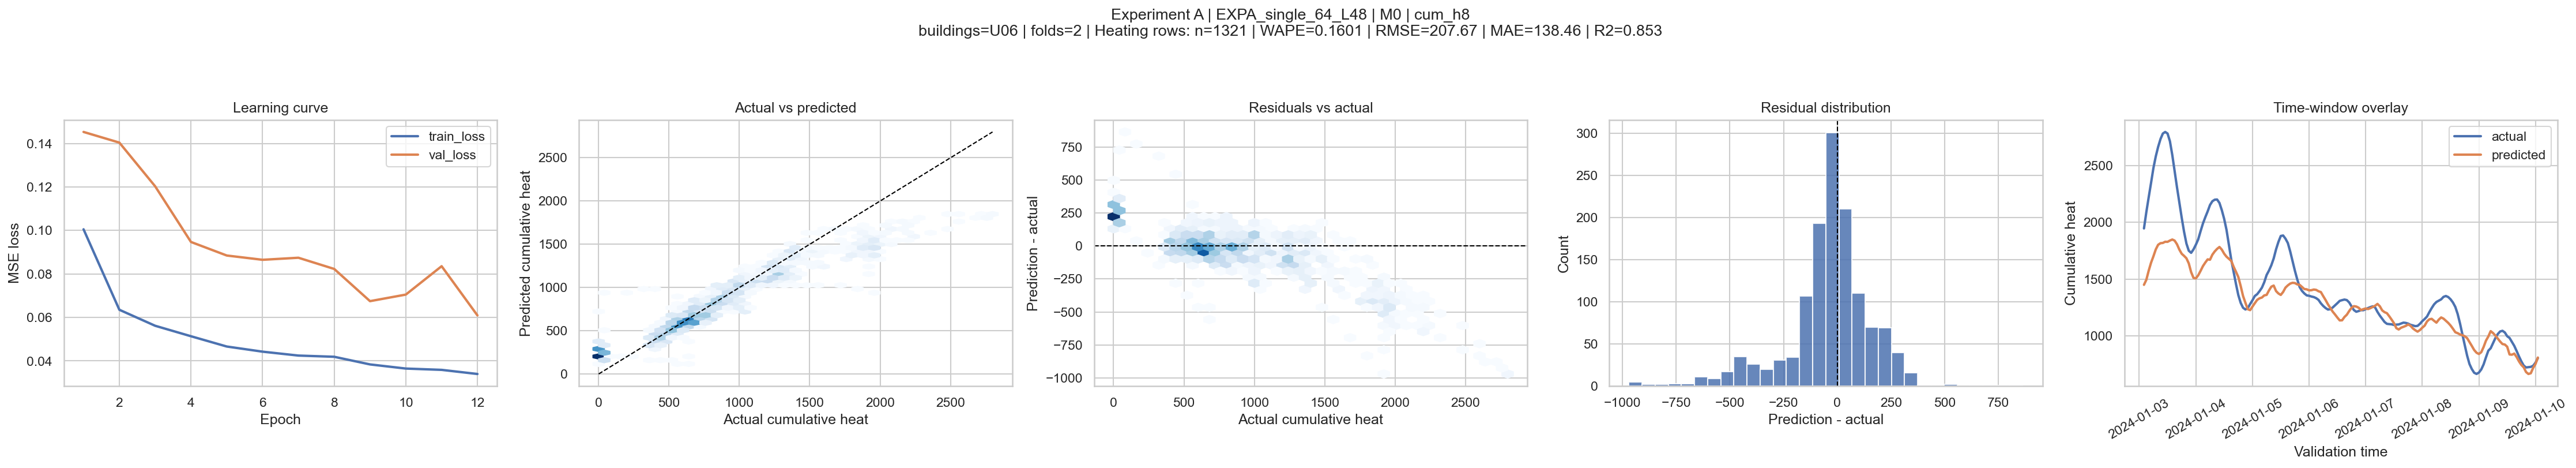

#### Preview: EXPA_single_64_L72 | lookback=72h | cum_h8  \nMean WAPE=0.1845, Mean RMSE=188.62, Mean R2=0.669

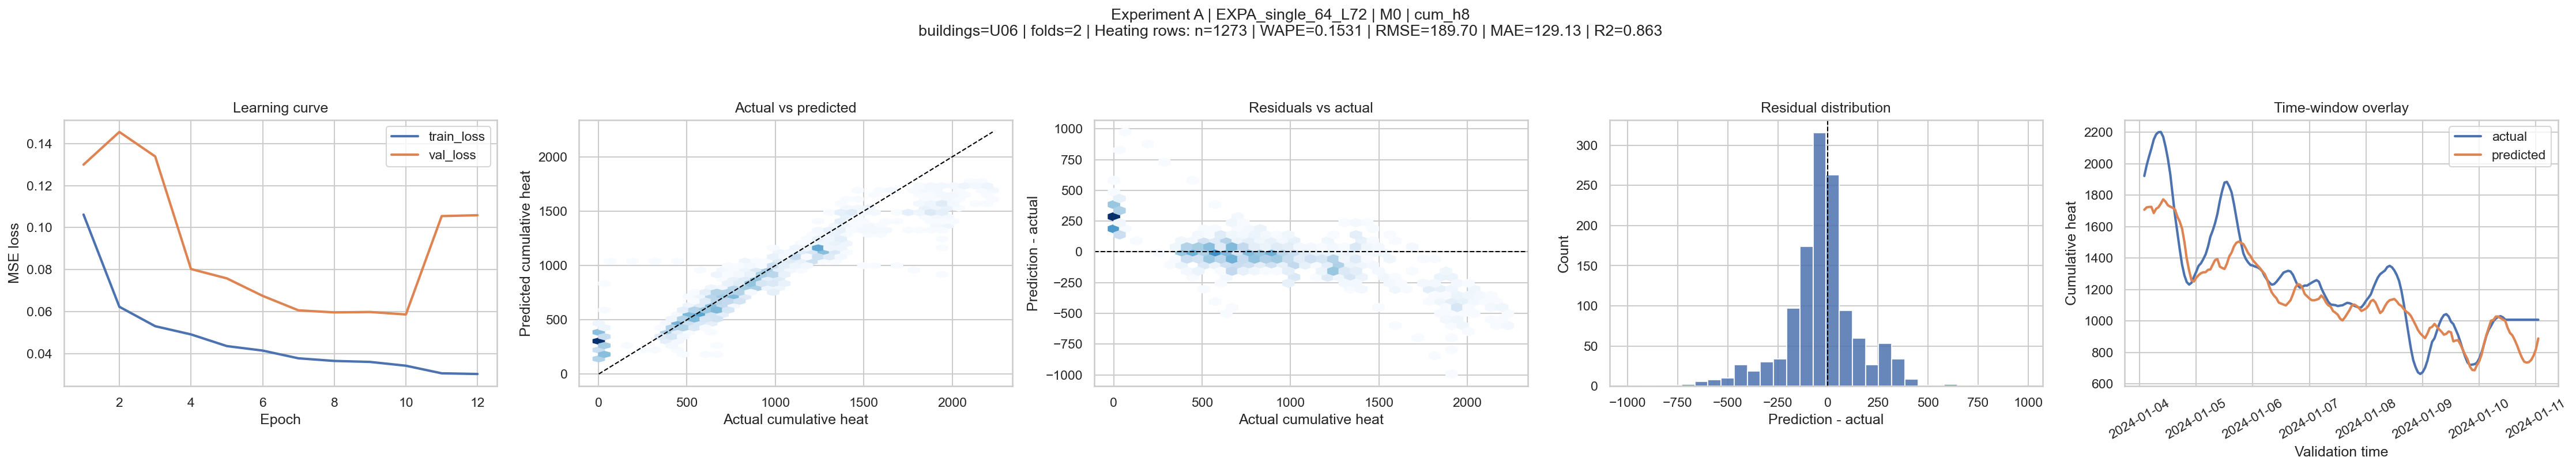

#### Preview: EXPA_single_64_L24 | lookback=24h | cum_h8  \nMean WAPE=0.1880, Mean RMSE=212.16, Mean R2=0.647

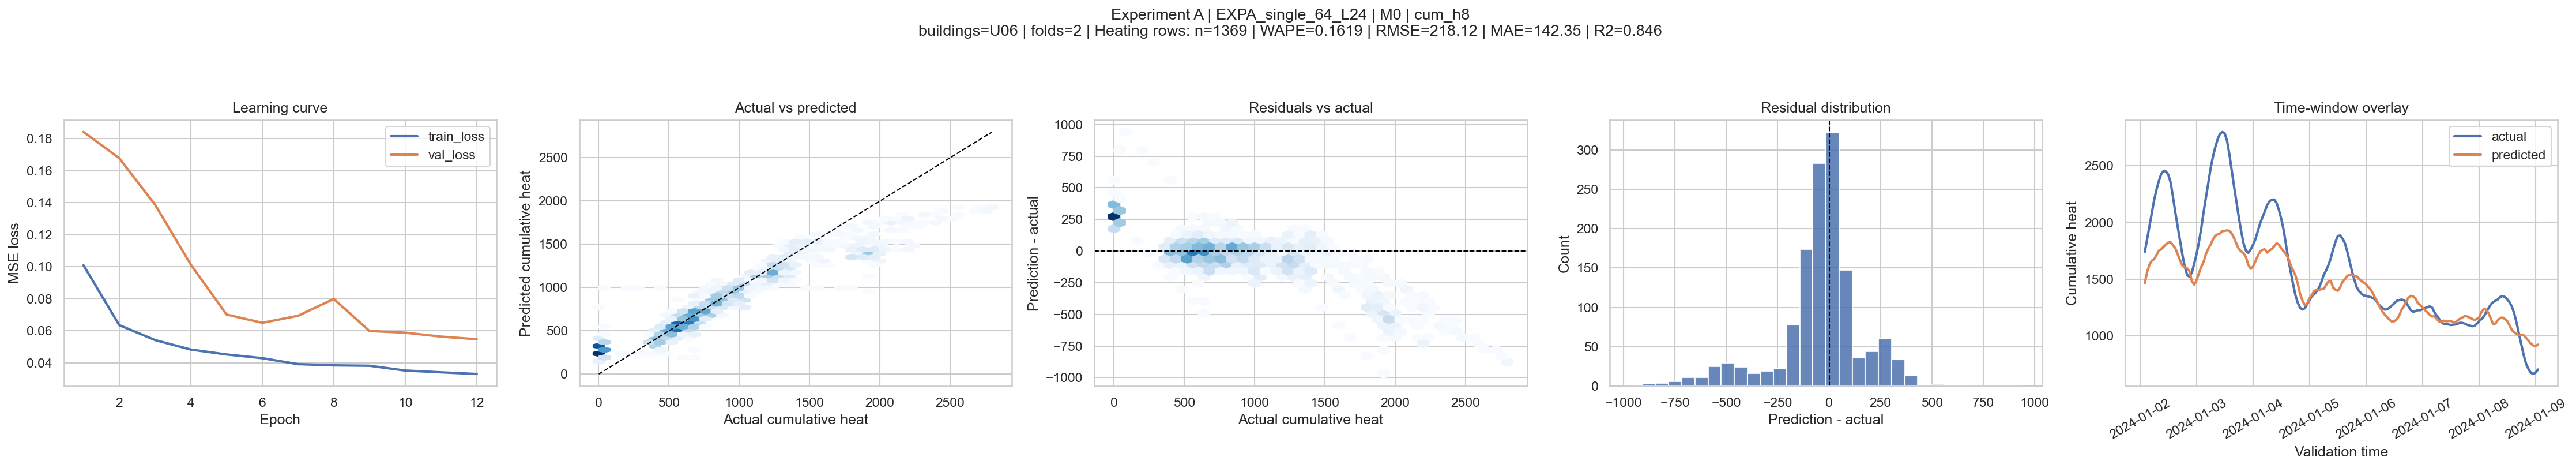

#### Preview: EXPA_single_64_L1 | lookback=1h | cum_h8  \nMean WAPE=0.1896, Mean RMSE=208.09, Mean R2=0.664

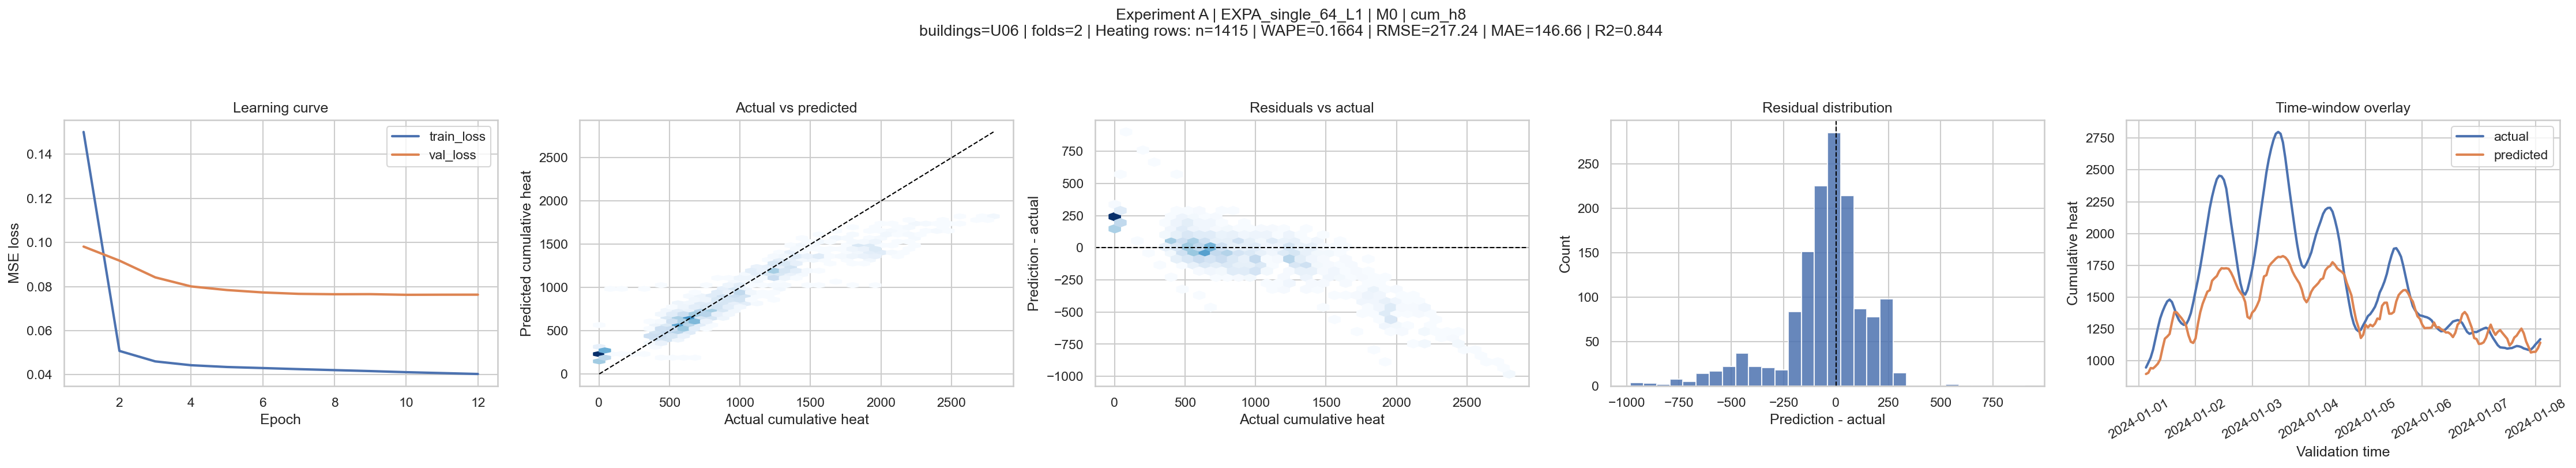

In [22]:
# Step 5 Experiment A summary and plots: shortlist useful lookbacks and explain what the panels show

if exp_a_results_df.empty:
    raise ValueError('Experiment A produced no results. Inspect the sequence setup before moving to Experiment B.')

exp_a_plot_index_df = render_evaluation_panels(
    exp_a_predictions_df,
    exp_a_history_store,
    EXPA_PLOT_DIR,
    filename_prefix='experiment_a',
    title_prefix='Experiment A',
)

exp_a_detail_summary_df = summarise_heating_results(
    exp_a_results_df,
    group_cols=['architecture_id', 'family_id', 'lookback_hours', 'horizon_hours'],
    catalog_df=exp_a_catalog_df,
).sort_values(['horizon_hours', 'mean_wape', 'mean_rmse', 'lookback_hours']).reset_index(drop=True)

exp_a_family_lookback_summary_df = (
    exp_a_results_df.loc[exp_a_results_df['slice_name'] == 'heating_season_rows']
    .groupby(['family_id', 'lookback_hours'], as_index=False)
    .agg(
        mean_wape=('wape', 'mean'),
        mean_rmse=('rmse', 'mean'),
        mean_mae=('mae', 'mean'),
        mean_r2=('r2', 'mean'),
        n_runs=('fold_id', 'count'),
    )
    .merge(exp_a_catalog_df[['family_id', 'family_label']].drop_duplicates(), on='family_id', how='left')
    .sort_values(['family_id', 'mean_wape', 'lookback_hours'])
    .reset_index(drop=True)
)

exp_a_lookback_summary_df = (
    exp_a_results_df.loc[exp_a_results_df['slice_name'] == 'heating_season_rows']
    .groupby('lookback_hours', as_index=False)
    .agg(
        mean_wape=('wape', 'mean'),
        std_wape=('wape', 'std'),
        mean_rmse=('rmse', 'mean'),
        mean_mae=('mae', 'mean'),
        mean_r2=('r2', 'mean'),
        n_runs=('fold_id', 'count'),
    )
    .sort_values(['mean_wape', 'mean_rmse', 'lookback_hours'])
    .reset_index(drop=True)
)

exp_a_family_summary_df = (
    exp_a_results_df.loc[exp_a_results_df['slice_name'] == 'heating_season_rows']
    .groupby('family_id', as_index=False)
    .agg(
        mean_wape=('wape', 'mean'),
        mean_rmse=('rmse', 'mean'),
        mean_mae=('mae', 'mean'),
        mean_r2=('r2', 'mean'),
        n_runs=('fold_id', 'count'),
    )
    .merge(exp_a_catalog_df[['family_id', 'family_label']].drop_duplicates(), on='family_id', how='left')
    .sort_values(['mean_wape', 'mean_rmse'])
    .reset_index(drop=True)
)

exp_a_detail_summary_df.to_csv(STEP5_EXPA_SUMMARY_FILE, index=False)
exp_a_lookback_summary_df.to_csv(STEP5_EXPA_LOOKBACK_FILE, index=False)

best_nontrivial_wape = exp_a_lookback_summary_df.loc[exp_a_lookback_summary_df['lookback_hours'] > 1, 'mean_wape'].min()
lb1_rows = exp_a_lookback_summary_df.loc[exp_a_lookback_summary_df['lookback_hours'] == 1]
lb1_wape = float(lb1_rows.iloc[0]['mean_wape']) if not lb1_rows.empty else np.nan
sequence_context_gain = float(lb1_wape - best_nontrivial_wape) if pd.notna(lb1_wape) and pd.notna(best_nontrivial_wape) else np.nan
sequence_context_is_helpful = bool(pd.notna(sequence_context_gain) and sequence_context_gain > LOOKBACK_TIE_BAND)
shortlisted_lookbacks = choose_shortlisted_lookbacks(exp_a_lookback_summary_df)
preferred_family_id = exp_a_family_summary_df.iloc[0]['family_id']
preferred_family_label = exp_a_family_summary_df.iloc[0]['family_label']

architecture_cheatsheet_df = architecture_reference_df.rename(columns={
    'architecture_id': 'model',
    'lookback_hours': 'lookback_h',
    'lstm_stack': 'lstm_units',
    'dense_units': 'dense_h',
})[['model', 'family_id', 'family_label', 'lookback_h', 'lstm_units', 'dropout', 'dense_h', 'what_it_tests']]

display(Markdown("""
### Experiment A plot guide

- The actual-vs-predicted and residual panels now use denser plotting because repeated temporal trajectories can make ordinary scatter plots look like loops.
- A systematic **downward** residual slope means the model is underpredicting higher-demand cumulative cases.
- A **flattened prediction ceiling** in the actual-vs-predicted panel suggests saturation: the model is compressing peaks instead of following the full target range.
- In this audit, those patterns can come from insufficient context, insufficient capacity, or target-scaling behaviour, so they should be interpreted together with the lookback comparisons rather than in isolation.
"""))

display(architecture_cheatsheet_df)
display(exp_a_detail_summary_df)
display(exp_a_family_lookback_summary_df)
display(exp_a_lookback_summary_df)
display(exp_a_plot_index_df)
print(f'Saved Experiment A summary to {STEP5_EXPA_SUMMARY_FILE}')
print(f'Saved Experiment A lookback summary to {STEP5_EXPA_LOOKBACK_FILE}')

exp_a_preview_df = (
    exp_a_detail_summary_df[['architecture_id', 'family_id', 'lookback_hours', 'horizon_hours', 'mean_wape', 'mean_rmse', 'mean_r2']]
    .sort_values(['mean_wape', 'mean_rmse', 'lookback_hours'])
    .head(4)
    .merge(exp_a_plot_index_df, on=['architecture_id', 'horizon_hours'], how='left')
)
if 'mode' not in exp_a_preview_df.columns:
    exp_a_preview_df['mode'] = 'M0'

display(exp_a_preview_df)
for _, row in exp_a_preview_df.iterrows():
    display(Markdown(
        f"#### Preview: {row['architecture_id']} | lookback={int(row['lookback_hours'])}h | cum_h{int(row['horizon_hours'])}  \\n"
        f"Mean WAPE={row['mean_wape']:.4f}, Mean RMSE={row['mean_rmse']:.2f}, Mean R2={row['mean_r2']:.3f}"
    ))
    if pd.notna(row.get('plot_path')):
        display(Image(filename=str(row['plot_path'])))


In [23]:
# Step 5 conclusion: decide whether sequence context is justified before testing feature-memory redundancy

sequence_context_text = 'yes' if sequence_context_is_helpful else 'not clearly yet'
next_step_text = (
    'Sequence context appears useful enough to keep lookback as a real tuning axis.'
    if sequence_context_is_helpful
    else 'Lookback=1 is close enough to the longer windows that the next phase should treat lookback more cautiously and keep the comparison small.'
)

display(Markdown(f"""
### Step 5 conclusion

- **Experiment A scope:** building `U06`, mode `M0`, horizons `{EXPERIMENT_HORIZONS}`, validation months `{EXPERIMENT_VALIDATION_MONTHS}`
- **`lookback=1` mean WAPE:** `{lb1_wape:.4f}`
- **Best `lookback>1` mean WAPE:** `{best_nontrivial_wape:.4f}`
- **Sequence-context gain versus `lookback=1`:** `{sequence_context_gain:.4f}`
- **Is sequence context helping?** `{sequence_context_text}`
- **Shortlisted lookbacks for Experiment B:** `{shortlisted_lookbacks}`
- **Preferred topology family carried into Experiment B:** `{preferred_family_label}` (`{preferred_family_id}`)
- **Experiment A figures saved under:** `{EXPA_PLOT_DIR}`

{next_step_text}

Experiment B should now hold the topology family fixed and ask whether `M1` adds anything beyond the sequence itself.
"""))



### Step 5 conclusion

- **Experiment A scope:** building `U06`, mode `M0`, horizons `[8, 24, 36]`, validation months `['2024-01', '2024-11']`
- **`lookback=1` mean WAPE:** `0.2235`
- **Best `lookback>1` mean WAPE:** `0.2136`
- **Sequence-context gain versus `lookback=1`:** `0.0099`
- **Is sequence context helping?** `yes`
- **Shortlisted lookbacks for Experiment B:** `[48, 72]`
- **Preferred topology family carried into Experiment B:** `single 64` (`single_64`)
- **Experiment A figures saved under:** `/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_a`

Sequence context appears useful enough to keep lookback as a real tuning axis.

Experiment B should now hold the topology family fixed and ask whether `M1` adds anything beyond the sequence itself.


## Step 6 - Experiment B and Experiment C

Step 6 now has two jobs, in this order:

1. **Experiment B: feature-memory redundancy audit**
   Keep the topology family fixed and compare `M0` against `M1` at the shortlisted lookbacks from Experiment A.
2. **Experiment C: fixed-lookback architecture comparison**
   Only after Experiment B chooses the working mode and lookback, compare the broader architecture families on `U06`, then confirm on `U05`.

This keeps sequence memory, engineered weather memory, and architecture complexity from moving all at once.


In [24]:
# Step 6 Experiment B: compare M0 vs M1 after lookback has been narrowed down

if not shortlisted_lookbacks:
    raise ValueError('Experiment A did not produce any shortlisted lookbacks for Experiment B.')

exp_b_catalog_df = build_experiment_b_catalog(shortlisted_lookbacks, preferred_family_id)
display(exp_b_catalog_df)
print(
    'Running Experiment B with',
    len(EXPB_BUILDINGS), 'building,',
    len(MODE_FEATURES), 'modes,',
    len(EXPERIMENT_HORIZONS), 'horizons,',
    len(EXPERIMENT_VALIDATION_MONTHS), 'validation months, and',
    len(exp_b_catalog_df), 'lookback rows.'
)

exp_b_results_df, exp_b_predictions_df, exp_b_history_store = run_architecture_scan(
    run_label='experiment_b',
    run_config=EXPB_CONFIG,
    catalog_df=exp_b_catalog_df,
    mode_features=MODE_FEATURES,
    selected_buildings=EXPB_BUILDINGS,
    selected_horizons=EXPERIMENT_HORIZONS,
    selected_validation_months=EXPERIMENT_VALIDATION_MONTHS,
)

exp_b_results_df.to_csv(STEP6_EXPB_RESULTS_FILE, index=False)
exp_b_predictions_df.to_csv(STEP6_EXPB_PREDICTIONS_FILE, index=False)

if exp_b_results_df.empty:
    raise ValueError('Experiment B produced no results. Inspect the selected lookbacks and feature modes before running Experiment C.')

exp_b_plot_index_df = render_evaluation_panels(
    exp_b_predictions_df,
    exp_b_history_store,
    EXPB_PLOT_DIR,
    filename_prefix='experiment_b',
    title_prefix='Experiment B',
)

exp_b_detail_summary_df = summarise_heating_results(
    exp_b_results_df,
    group_cols=['architecture_id', 'mode', 'lookback_hours', 'horizon_hours'],
    catalog_df=exp_b_catalog_df,
).sort_values(['mode', 'horizon_hours', 'mean_wape', 'mean_rmse', 'lookback_hours']).reset_index(drop=True)

exp_b_mode_lookback_summary_df = (
    exp_b_results_df.loc[exp_b_results_df['slice_name'] == 'heating_season_rows']
    .groupby(['mode', 'lookback_hours'], as_index=False)
    .agg(
        mean_wape=('wape', 'mean'),
        mean_rmse=('rmse', 'mean'),
        mean_mae=('mae', 'mean'),
        mean_r2=('r2', 'mean'),
        n_runs=('fold_id', 'count'),
    )
    .sort_values(['mean_wape', 'mean_rmse', 'lookback_hours', 'mode'])
    .reset_index(drop=True)
)

best_exp_b_row = exp_b_mode_lookback_summary_df.iloc[0].copy()
selected_mode = best_exp_b_row['mode']
selected_lookback = int(best_exp_b_row['lookback_hours'])
if selected_mode == 'M1':
    m0_same_lb = exp_b_mode_lookback_summary_df.loc[
        (exp_b_mode_lookback_summary_df['mode'] == 'M0')
        & (exp_b_mode_lookback_summary_df['lookback_hours'] == selected_lookback)
    ]
    if not m0_same_lb.empty and float(m0_same_lb.iloc[0]['mean_wape']) <= float(best_exp_b_row['mean_wape']) + MODE_TIE_BAND:
        best_exp_b_row = m0_same_lb.iloc[0].copy()
        selected_mode = 'M0'
        selected_lookback = int(best_exp_b_row['lookback_hours'])

exp_b_detail_summary_df.to_csv(STEP6_EXPB_SUMMARY_FILE, index=False)

display(Markdown("""
### Experiment B interpretation note

This comparison asks whether the explicit weather-memory feature `feat_temp_roll24h` still helps once the LSTM already sees a temporal window of engineered weather rows. If `M1` is only marginally better than `M0`, the cleaner choice is to keep `M0` and avoid adding redundant memory into the architecture decision.
"""))

display(exp_b_detail_summary_df)
display(exp_b_mode_lookback_summary_df)
display(exp_b_plot_index_df)
print(f'Saved Experiment B detailed results to {STEP6_EXPB_RESULTS_FILE}')
print(f'Saved Experiment B summary to {STEP6_EXPB_SUMMARY_FILE}')
print(f'Experiment B selected mode/lookback: mode={selected_mode}, lookback={selected_lookback}h')


,architecture_id,family_id,family_label,lookback_hours,lstm_stack,dropout,dense_units,notes
0,EXPB_single_64_L48,single_64,single 64,48,64,0.0,16,Experiment B: fixed topology family to test M0 vs M1.
1,EXPB_single_64_L72,single_64,single 64,72,64,0.0,16,Experiment B: fixed topology family to test M0 vs M1.


Running Experiment B with 1 building, 2 modes, 3 horizons, 2 validation months, and 2 lookback rows.


experiment_b scan: 100%|██████████| 24/24 [20:24<00:00, 51.02s/it, U06 M1 h36 EXPB_single_64_L72 2024-11]



### Experiment B interpretation note

This comparison asks whether the explicit weather-memory feature `feat_temp_roll24h` still helps once the LSTM already sees a temporal window of engineered weather rows. If `M1` is only marginally better than `M0`, the cleaner choice is to keep `M0` and avoid adding redundant memory into the architecture decision.


,architecture_id,mode,lookback_hours,horizon_hours,mean_wape,std_wape,mean_rmse,mean_mae,mean_r2,n_runs,family_label,lstm_stack,dropout,dense_units,notes
0,EXPB_single_64_L72,M0,72,8,0.173287,0.087499,180.461290,121.405790,0.696129,2,single 64,64,0.0,16,Experiment B: fixed topology family to test M0 vs M1.
1,EXPB_single_64_L48,M0,48,8,0.174216,0.065163,194.993780,131.168378,0.699315,2,single 64,64,0.0,16,Experiment B: fixed topology family to test M0 vs M1.
2,EXPB_single_64_L48,M0,48,24,0.192977,0.061991,660.115244,440.980668,0.551367,2,single 64,64,0.0,16,Experiment B: fixed topology family to test M0 vs M1.
3,EXPB_single_64_L72,M0,72,24,0.199455,0.095894,620.331533,420.064612,0.550030,2,single 64,64,0.0,16,Experiment B: fixed topology family to test M0 vs M1.
4,EXPB_single_64_L48,M0,48,36,0.209972,0.084116,1025.478643,694.863318,0.460044,2,single 64,64,0.0,16,Experiment B: fixed topology family to test M0 vs M1.
5,EXPB_single_64_L72,M0,72,36,0.237620,0.105864,1094.581754,757.229051,0.348047,2,single 64,64,0.0,16,Experiment B: fixed topology family to test M0 vs M1.
6,EXPB_single_64_L48,M1,48,8,0.177721,0.086108,192.770962,128.300208,0.686258,2,single 64,64,0.0,16,Experiment B: fixed topology family to test M0 vs M1.
7,EXPB_single_64_L72,M1,72,8,0.186140,0.102212,187.221793,128.198290,0.671106,2,single 64,64,0.0,16,Experiment B: fixed topology family to test M0 vs M1.
8,EXPB_single_64_L48,M1,48,24,0.194777,0.066341,657.359850,441.991911,0.548581,2,single 64,64,0.0,16,Experiment B: fixed topology family to test M0 vs M1.
9,EXPB_single_64_L72,M1,72,24,0.227842,0.110420,679.802014,479.150171,0.463213,2,single 64,64,0.0,16,Experiment B: fixed topology family to test M0 vs M1.


,mode,lookback_hours,mean_wape,mean_rmse,mean_mae,mean_r2,n_runs
0,M0,48,0.192388,626.862555,422.337455,0.570242,6
1,M1,48,0.199935,656.321138,446.189209,0.535135,6
2,M0,72,0.203454,631.791525,432.899817,0.531402,6
3,M1,72,0.218143,638.364034,447.643632,0.503183,6


,architecture_id,mode,horizon_hours,plot_path
0,EXPB_single_64_L48,M0,8,/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_b/experiment_b_EXPB_single_64_L48_M0_cum_h8.png
1,EXPB_single_64_L48,M0,24,/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_b/experiment_b_EXPB_single_64_L48_M0_cum_h24.png
2,EXPB_single_64_L48,M0,36,/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_b/experiment_b_EXPB_single_64_L48_M0_cum_h36.png
3,EXPB_single_64_L48,M1,8,/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_b/experiment_b_EXPB_single_64_L48_M1_cum_h8.png
4,EXPB_single_64_L48,M1,24,/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_b/experiment_b_EXPB_single_64_L48_M1_cum_h24.png
5,EXPB_single_64_L48,M1,36,/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_b/experiment_b_EXPB_single_64_L48_M1_cum_h36.png
6,EXPB_single_64_L72,M0,8,/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_b/experiment_b_EXPB_single_64_L72_M0_cum_h8.png
7,EXPB_single_64_L72,M0,24,/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_b/experiment_b_EXPB_single_64_L72_M0_cum_h24.png
8,EXPB_single_64_L72,M0,36,/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_b/experiment_b_EXPB_single_64_L72_M0_cum_h36.png
9,EXPB_single_64_L72,M1,8,/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_b/experiment_b_EXPB_single_64_L72_M1_cum_h8.png


Saved Experiment B detailed results to /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_experiment_b_20032026.csv
Saved Experiment B summary to /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_experiment_b_summary_20032026.csv
Experiment B selected mode/lookback: mode=M0, lookback=48h


,architecture_id,family_id,family_label,lookback_hours,lstm_stack,dropout,dense_units,notes
0,EXPC_stack_64_32_L48,stack_64_32,stacked 64 -> 32,48,64 -> 32,0.2,16,Experiment C: fixed-lookback architecture comparison.
1,EXPC_single_64_L48,single_64,single 64,48,64,0.0,16,Experiment C: fixed-lookback architecture comparison.
2,EXPC_single_128_L48,single_128,single 128,48,128,0.0,16,Experiment C: fixed-lookback architecture comparison.
3,EXPC_stack_128_64_L48,stack_128_64,stacked 128 -> 64,48,128 -> 64,0.2,32,Experiment C: fixed-lookback architecture comparison.


experiment_c_u05 scan: 100%|██████████| 24/24 [28:47<00:00, 71.99s/it, U05 M0 h36 EXPC_stack_128_64_L48 2024-11]



### Experiment C note

This is the first *clean* architecture comparison after the lookback and feature-memory questions have been narrowed down. It should be interpreted as a candidate architecture shortlist for wider confirmation, not yet as the final thesis-wide lock across every building.


,architecture_id,family_id,lookback_hours,u06_mean_wape,u06_std_wape,u06_mean_rmse,u06_mean_mae,u06_mean_r2,u06_n_runs,family_label,...,complexity_score,combined_mean_wape,combined_mean_rmse,best_u06_wape,best_u05_wape,passes_u06_anchor,passes_u05_confirm,eligible_for_tentative_lock,architecture_lock_status,chosen_architecture
0,EXPC_single_64_L48,single_64,48,0.201098,0.068714,632.661992,434.152614,0.542500,6,single 64,...,106608,0.223549,652.194883,0.201098,0.245999,True,True,True,tentatively_locked_for_wider_confirmation,EXPC_single_64_L48
1,EXPC_single_128_L48,single_128,48,0.219777,0.100133,685.002959,457.476856,0.426694,6,single 128,...,113008,0.246022,686.676843,0.201098,0.245999,False,False,False,tentatively_locked_for_wider_confirmation,EXPC_single_64_L48
2,EXPC_stack_64_32_L48,stack_64_32,48,0.232727,0.080911,734.690945,502.873976,0.388837,6,stacked 64 -> 32,...,209808,0.266153,760.526836,0.201098,0.245999,False,False,False,tentatively_locked_for_wider_confirmation,EXPC_single_64_L48
3,EXPC_stack_128_64_L48,stack_128_64,48,0.232560,0.056706,709.275886,494.004520,0.392180,6,stacked 128 -> 64,...,219568,0.355965,924.272148,0.201098,0.245999,False,False,False,tentatively_locked_for_wider_confirmation,EXPC_single_64_L48


,architecture_id,mode,horizon_hours,plot_path
0,EXPC_single_128_L48,M0,8,/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_c/U06/experiment_c_u06_EXPC_single_128_L48_M0_cum_h8.png
1,EXPC_single_128_L48,M0,24,/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_c/U06/experiment_c_u06_EXPC_single_128_L48_M0_cum_h24.png
2,EXPC_single_128_L48,M0,36,/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_c/U06/experiment_c_u06_EXPC_single_128_L48_M0_cum_h36.png
3,EXPC_single_64_L48,M0,8,/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_c/U06/experiment_c_u06_EXPC_single_64_L48_M0_cum_h8.png
4,EXPC_single_64_L48,M0,24,/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_c/U06/experiment_c_u06_EXPC_single_64_L48_M0_cum_h24.png
5,EXPC_single_64_L48,M0,36,/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_c/U06/experiment_c_u06_EXPC_single_64_L48_M0_cum_h36.png
6,EXPC_stack_128_64_L48,M0,8,/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_c/U06/experiment_c_u06_EXPC_stack_128_64_L48_M0_cum_h8.png
7,EXPC_stack_128_64_L48,M0,24,/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_c/U06/experiment_c_u06_EXPC_stack_128_64_L48_M0_cum_h24.png
8,EXPC_stack_128_64_L48,M0,36,/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_c/U06/experiment_c_u06_EXPC_stack_128_64_L48_M0_cum_h36.png
9,EXPC_stack_64_32_L48,M0,8,/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_c/U06/experiment_c_u06_EXPC_stack_64_32_L48_M0_cum_h8.png


,architecture_id,mode,horizon_hours,plot_path
0,EXPC_single_128_L48,M0,8,/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_c/U05/experiment_c_u05_EXPC_single_128_L48_M0_cum_h8.png
1,EXPC_single_128_L48,M0,24,/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_c/U05/experiment_c_u05_EXPC_single_128_L48_M0_cum_h24.png
2,EXPC_single_128_L48,M0,36,/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_c/U05/experiment_c_u05_EXPC_single_128_L48_M0_cum_h36.png
3,EXPC_single_64_L48,M0,8,/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_c/U05/experiment_c_u05_EXPC_single_64_L48_M0_cum_h8.png
4,EXPC_single_64_L48,M0,24,/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_c/U05/experiment_c_u05_EXPC_single_64_L48_M0_cum_h24.png
5,EXPC_single_64_L48,M0,36,/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_c/U05/experiment_c_u05_EXPC_single_64_L48_M0_cum_h36.png
6,EXPC_stack_128_64_L48,M0,8,/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_c/U05/experiment_c_u05_EXPC_stack_128_64_L48_M0_cum_h8.png
7,EXPC_stack_128_64_L48,M0,24,/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_c/U05/experiment_c_u05_EXPC_stack_128_64_L48_M0_cum_h24.png
8,EXPC_stack_128_64_L48,M0,36,/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_c/U05/experiment_c_u05_EXPC_stack_128_64_L48_M0_cum_h36.png
9,EXPC_stack_64_32_L48,M0,8,/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_c/U05/experiment_c_u05_EXPC_stack_64_32_L48_M0_cum_h8.png


Saved Experiment C U06 results to /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_experiment_c_u06_20032026.csv
Saved Experiment C U05 confirmation results to /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_experiment_c_u05_20032026.csv
Saved Experiment C selection summary to /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_selection_summary_20032026.csv


#### Experiment C preview: `EXPC_single_64_L48`

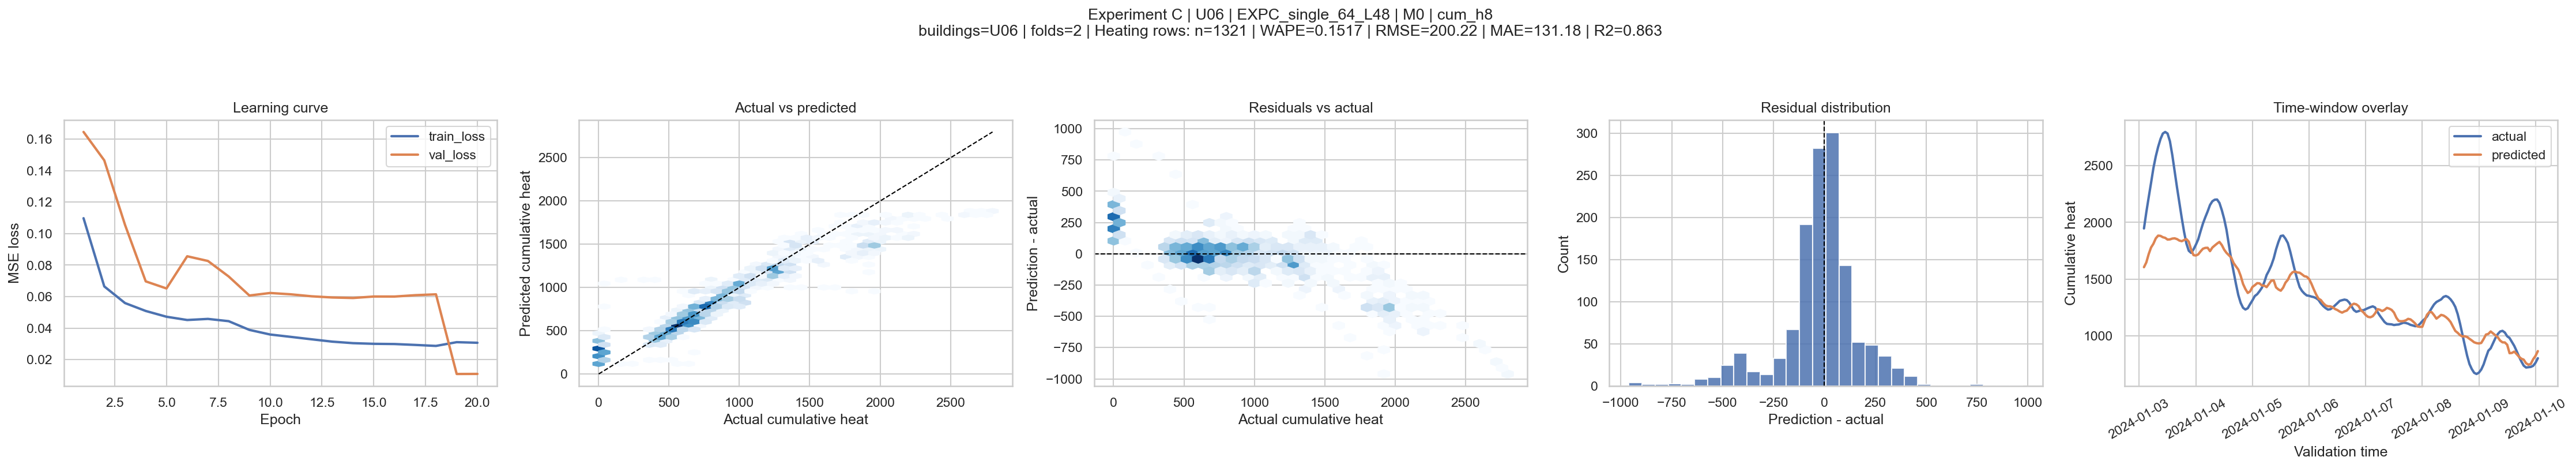

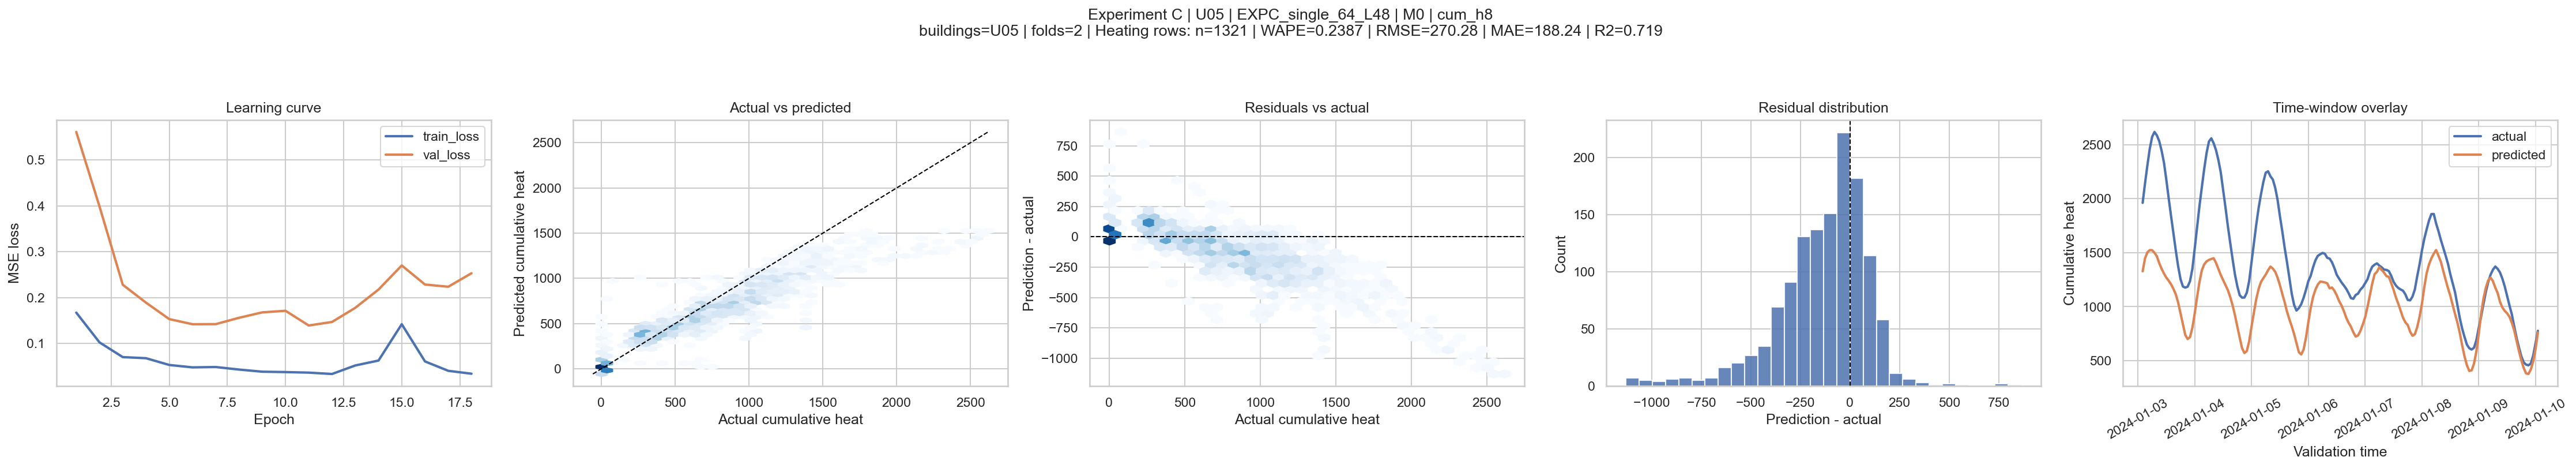

#### Experiment C preview: `EXPC_single_128_L48`

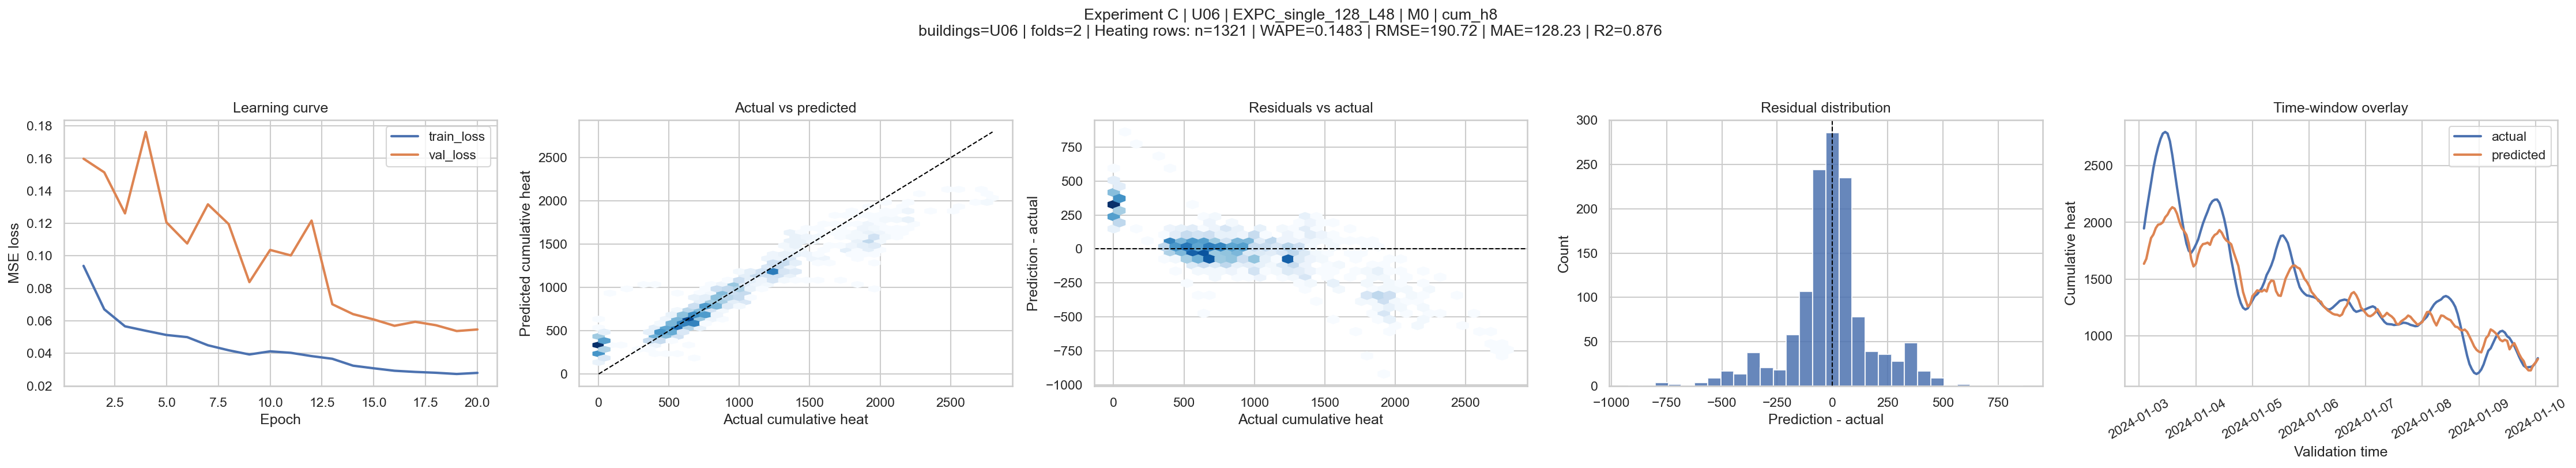

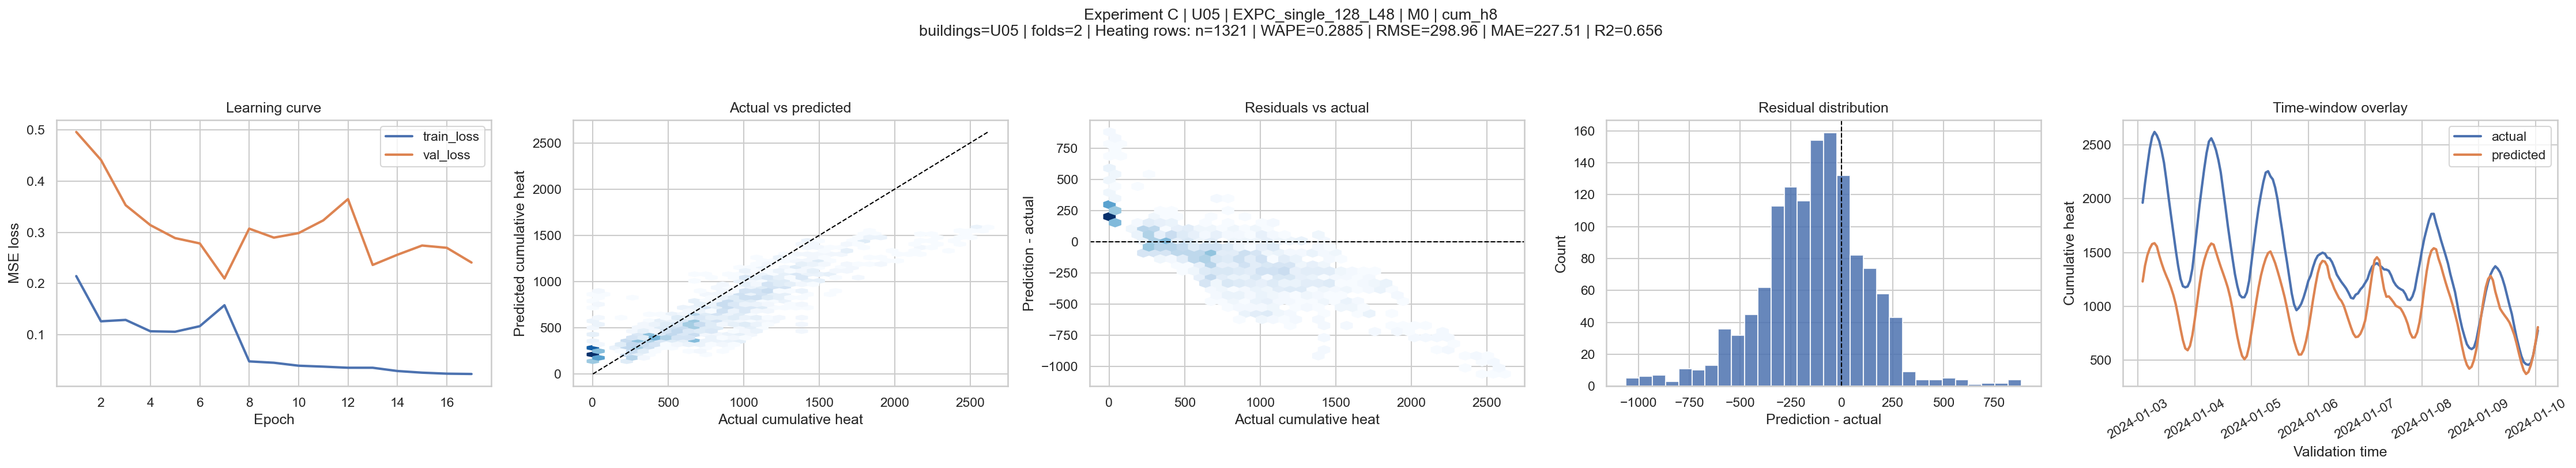

In [25]:
# Step 6 Experiment C and selection summary: fix the lookback first, then compare architecture families on U06 and confirm on U05

exp_c_catalog_df = build_experiment_c_catalog(selected_lookback)
display(exp_c_catalog_df)

selected_mode_features = {selected_mode: MODE_FEATURES[selected_mode]}

exp_c_u06_results_df, exp_c_u06_predictions_df, exp_c_u06_history_store = run_architecture_scan(
    run_label='experiment_c_u06',
    run_config=EXPC_CONFIG,
    catalog_df=exp_c_catalog_df,
    mode_features=selected_mode_features,
    selected_buildings=['U06'],
    selected_horizons=EXPERIMENT_HORIZONS,
    selected_validation_months=EXPERIMENT_VALIDATION_MONTHS,
)
exp_c_u06_results_df.to_csv(STEP6_EXPC_U06_RESULTS_FILE, index=False)
exp_c_u06_predictions_df.to_csv(STEP6_EXPC_U06_PREDICTIONS_FILE, index=False)

exp_c_u05_results_df, exp_c_u05_predictions_df, exp_c_u05_history_store = run_architecture_scan(
    run_label='experiment_c_u05',
    run_config=EXPC_CONFIG,
    catalog_df=exp_c_catalog_df,
    mode_features=selected_mode_features,
    selected_buildings=EXPC_CONFIRM_BUILDINGS,
    selected_horizons=EXPERIMENT_HORIZONS,
    selected_validation_months=EXPERIMENT_VALIDATION_MONTHS,
)
exp_c_u05_results_df.to_csv(STEP6_EXPC_U05_RESULTS_FILE, index=False)
exp_c_u05_predictions_df.to_csv(STEP6_EXPC_U05_PREDICTIONS_FILE, index=False)

if exp_c_u06_results_df.empty:
    raise ValueError('Experiment C on U06 produced no results. Architecture comparison cannot continue.')

exp_c_u06_plot_index_df = render_evaluation_panels(
    exp_c_u06_predictions_df,
    exp_c_u06_history_store,
    EXPC_PLOT_DIR / 'U06',
    filename_prefix='experiment_c_u06',
    title_prefix='Experiment C | U06',
)
exp_c_u05_plot_index_df = render_evaluation_panels(
    exp_c_u05_predictions_df,
    exp_c_u05_history_store,
    EXPC_PLOT_DIR / 'U05',
    filename_prefix='experiment_c_u05',
    title_prefix='Experiment C | U05',
)

exp_c_u06_summary_df = summarise_heating_results(
    exp_c_u06_results_df,
    group_cols=['architecture_id', 'family_id', 'lookback_hours'],
    catalog_df=exp_c_catalog_df,
).rename(columns={
    'mean_wape': 'u06_mean_wape',
    'mean_rmse': 'u06_mean_rmse',
    'mean_mae': 'u06_mean_mae',
    'mean_r2': 'u06_mean_r2',
    'n_runs': 'u06_n_runs',
    'std_wape': 'u06_std_wape',
})

exp_c_u05_summary_df = summarise_heating_results(
    exp_c_u05_results_df,
    group_cols=['architecture_id', 'family_id', 'lookback_hours'],
    catalog_df=exp_c_catalog_df,
).rename(columns={
    'mean_wape': 'u05_mean_wape',
    'mean_rmse': 'u05_mean_rmse',
    'mean_mae': 'u05_mean_mae',
    'mean_r2': 'u05_mean_r2',
    'n_runs': 'u05_n_runs',
    'std_wape': 'u05_std_wape',
})

exp_c_selection_df = exp_c_u06_summary_df.merge(
    exp_c_u05_summary_df[['architecture_id', 'u05_mean_wape', 'u05_mean_rmse', 'u05_mean_mae', 'u05_mean_r2', 'u05_n_runs', 'u05_std_wape']],
    on='architecture_id',
    how='left',
)
exp_c_selection_df['complexity_score'] = exp_c_selection_df.apply(architecture_complexity_score, axis=1)
exp_c_selection_df['combined_mean_wape'] = exp_c_selection_df[['u06_mean_wape', 'u05_mean_wape']].mean(axis=1, skipna=True)
exp_c_selection_df['combined_mean_rmse'] = exp_c_selection_df[['u06_mean_rmse', 'u05_mean_rmse']].mean(axis=1, skipna=True)
exp_c_selection_df['best_u06_wape'] = exp_c_selection_df['u06_mean_wape'].min()
exp_c_selection_df['best_u05_wape'] = exp_c_selection_df['u05_mean_wape'].min() if exp_c_selection_df['u05_mean_wape'].notna().any() else np.nan
exp_c_selection_df['passes_u06_anchor'] = (exp_c_selection_df['u06_mean_wape'] - exp_c_selection_df['best_u06_wape']) <= 0.010
exp_c_selection_df['passes_u05_confirm'] = True if not exp_c_selection_df['u05_mean_wape'].notna().any() else (exp_c_selection_df['u05_mean_wape'] - exp_c_selection_df['best_u05_wape']) <= 0.010
exp_c_selection_df['eligible_for_tentative_lock'] = exp_c_selection_df['passes_u06_anchor'].fillna(False) & exp_c_selection_df['passes_u05_confirm'].fillna(False)
exp_c_selection_df = exp_c_selection_df.sort_values(['combined_mean_wape', 'combined_mean_rmse', 'complexity_score']).reset_index(drop=True)

top_architecture_ids = exp_c_selection_df['architecture_id'].head(2).tolist()
eligible_exp_c_df = exp_c_selection_df.loc[exp_c_selection_df['eligible_for_tentative_lock']].copy()
if eligible_exp_c_df.empty:
    chosen_architecture_id = None
    architecture_lock_status = 'not_lockable_yet'
else:
    best_combined_wape = eligible_exp_c_df['combined_mean_wape'].min()
    tied_df = eligible_exp_c_df.loc[(eligible_exp_c_df['combined_mean_wape'] - best_combined_wape) <= LOOKBACK_TIE_BAND].copy()
    tied_df = tied_df.sort_values(['complexity_score', 'combined_mean_rmse'])
    chosen_architecture_id = tied_df.iloc[0]['architecture_id']
    architecture_lock_status = 'tentatively_locked_for_wider_confirmation'

exp_c_selection_df['architecture_lock_status'] = architecture_lock_status
exp_c_selection_df['chosen_architecture'] = chosen_architecture_id
exp_c_selection_df.to_csv(STEP6_SELECTION_FILE, index=False)
exp_c_selection_df.to_csv(STEP6_EXPC_SUMMARY_FILE, index=False)

display(Markdown("""
### Experiment C note

This is the first *clean* architecture comparison after the lookback and feature-memory questions have been narrowed down. It should be interpreted as a candidate architecture shortlist for wider confirmation, not yet as the final thesis-wide lock across every building.
"""))

display(exp_c_selection_df)
display(exp_c_u06_plot_index_df)
display(exp_c_u05_plot_index_df)
print(f'Saved Experiment C U06 results to {STEP6_EXPC_U06_RESULTS_FILE}')
print(f'Saved Experiment C U05 confirmation results to {STEP6_EXPC_U05_RESULTS_FILE}')
print(f'Saved Experiment C selection summary to {STEP6_SELECTION_FILE}')

preview_architecture_ids = [arch_id for arch_id in [chosen_architecture_id] + top_architecture_ids if arch_id is not None]
preview_architecture_ids = list(dict.fromkeys(preview_architecture_ids))[:2]
for arch_id in preview_architecture_ids:
    display(Markdown(f'#### Experiment C preview: `{arch_id}`'))
    u06_plot = exp_c_u06_plot_index_df.loc[exp_c_u06_plot_index_df['architecture_id'] == arch_id, 'plot_path']
    if not u06_plot.empty:
        display(Image(filename=str(u06_plot.iloc[0])))
    u05_plot = exp_c_u05_plot_index_df.loc[exp_c_u05_plot_index_df['architecture_id'] == arch_id, 'plot_path']
    if not u05_plot.empty:
        display(Image(filename=str(u05_plot.iloc[0])))


In [26]:
# Step 6 conclusion: summarize the clarified audit path and the current candidate architecture

if chosen_architecture_id is None:
    follow_up_text = 'No architecture is lockable yet from the cleaned-up audit path. The next smallest follow-up should inspect why the leading families fail either the U06 anchor check or the U05 confirmation check, then rerun only that narrowed comparison.'
else:
    follow_up_text = f'Tentative shared architecture for wider confirmation: `{chosen_architecture_id}`. The next run should expand only this shortlist to the broader audit buildings, rather than reopening lookback and feature-memory at the same time.'

display(Markdown(f"""
### Step 6 conclusion

- **Sequence context helpful?** `{sequence_context_is_helpful}`
- **Experiment B selected mode:** `{selected_mode}`
- **Experiment B selected lookback:** `{selected_lookback}h`
- **Experiment C compared families:** `{', '.join(exp_c_catalog_df['family_label'].tolist())}`
- **Top current architecture shortlist:** `{', '.join(top_architecture_ids) if top_architecture_ids else 'none'}`
- **Architecture lock status:** `{architecture_lock_status}`
- **Chosen architecture:** `{chosen_architecture_id if chosen_architecture_id is not None else 'none'}`
- **Experiment C figures saved under:** `{EXPC_PLOT_DIR}`
- **Selection summary file:** `{STEP6_SELECTION_FILE}`

{follow_up_text}

At this point the notebook has answered the three narrower questions in the right order: what an LSTM sample is, whether sequence context matters, whether `M1` still helps once sequence context exists, and only then which architecture family currently looks strongest.
"""))



### Step 6 conclusion

- **Sequence context helpful?** `True`
- **Experiment B selected mode:** `M0`
- **Experiment B selected lookback:** `48h`
- **Experiment C compared families:** `stacked 64 -> 32, single 64, single 128, stacked 128 -> 64`
- **Top current architecture shortlist:** `EXPC_single_64_L48, EXPC_single_128_L48`
- **Architecture lock status:** `tentatively_locked_for_wider_confirmation`
- **Chosen architecture:** `EXPC_single_64_L48`
- **Experiment C figures saved under:** `/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_plots_20032026/experiment_c`
- **Selection summary file:** `/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/architecture_audit_selection_summary_20032026.csv`

Tentative shared architecture for wider confirmation: `EXPC_single_64_L48`. The next run should expand only this shortlist to the broader audit buildings, rather than reopening lookback and feature-memory at the same time.

At this point the notebook has answered the three narrower questions in the right order: what an LSTM sample is, whether sequence context matters, whether `M1` still helps once sequence context exists, and only then which architecture family currently looks strongest.


## After the clarified architecture audit

This notebook now reframes the architecture choice into the correct order:

- clarify the LSTM sample semantics first;
- test `lookback=1` versus longer windows before treating lookback as a major tuning axis;
- test `M0` versus `M1` only after lookback is narrowed down;
- compare broader architecture families only after those two questions are fixed.

The next thesis-facing phase should therefore be:

- wider confirmation of the shortlisted architecture on the remaining audit buildings;
- cumulative direct-vs-recursive comparison with the shortlisted architecture only;
- grouped feature ablation / PFI on the best cumulative model(s);
- optional XGBoost only after the cumulative LSTM foundation is stable.

Point forecasts may still exist internally where needed for recursive rollout, but the thesis-facing output should remain cumulative heat demand.
